<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%209/W09_L3_Transformers_for_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=N6XLRsZsHew) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%209/NPTEL_Jul24_DL4CV_W09_P03.pdf)

In [1]:
# Week 9, Lecture 3: Transformers for Segmentation
from IPython.display import HTML, display

VIDEO_ID = "N6XLRsZsHew"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 9, Lecture 3: Transformers for Segmentation

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§9.3 Transformers for Image Segmentation**.

This notebook follows the lecture from SETR to Segment Anything on one synthetic dataset of coloured shapes. Every architecture is built from small parts, trained for a few seconds and scored by mean IoU, so that the design choices the slides describe (a pure Transformer encoder, hierarchical features without positional encodings, mask classification instead of per-pixel classification, masked attention, promptable masks with three answers) become measured numbers rather than claims.

**What you will learn**
- **SETR**: segmentation as sequence-to-sequence prediction with a ViT encoder, and the **PUP** and **MLA** decoders
- **SegFormer**: overlapped patch merging, **efficient self-attention** with sequence reduction ($K, V$ from $N/R^2$ tokens, cost $O(N^2/R^2)$ instead of $O(N^2)$), the Mix-FFN that replaces positional encodings, and the all-MLP decoder
- **MaskFormer**: $N$ queries, each with a class distribution $p_i$ and a mask $m_i = \sigma(\mathcal{E}_{mask}(q_i) \cdot \mathcal{E}_{pixel})$, matched to the ground truth by the **Hungarian algorithm** and read out by marginalisation $\arg\max_c \sum_i p_i(c)\, m_i[h,w]$
- **Mask2Former**: masked attention $\mathrm{softmax}(\mathcal{M}_{l-1} + Q_l K_l^\top) V_l$, implemented as a boolean attention mask
- **SAM**: the promptable segmentation task; an image encoder, a point prompt encoder (positional encoding of the click plus a label embedding) and a mask decoder that returns **three masks and an IoU score**
- The **data engine** and SAM's zero-shot evaluations (automatic masks from a point grid, single-point valid masks, edge detection), reproduced in miniature
- **Grounded SAM**: Grounding DINO turns text into boxes, boxes prompt SAM

**Contents**

0. A synthetic segmentation dataset with parts, instances and groups
1. SETR: segmentation as sequence-to-sequence prediction
2. SegFormer: hierarchical features, efficient attention and an all-MLP decoder
3. MaskFormer: per-pixel classification is not all you need
4. Mask2Former: masked attention
5. Segment Anything: the promptable segmentation task
6. The SAM model: image encoder, prompt encoder, mask decoder
7. The data engine and zero-shot evaluation, in miniature
8. Grounded SAM: open-vocabulary detection and segmentation
9. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

The previous lecture (§9.2) brought transformers to detection. DETR reads an image as a sequence of features, feeds $N$ learned object queries to a Transformer decoder, and turns the $N$ outputs into a set of boxes and classes, matched to the ground truth by the Hungarian algorithm so that neither anchors nor non-maximum suppression are needed; Deformable DETR made the attention sparse and multi-scale. Segmentation, recalled at the start of this deck, partitions an image into regions, and the CNNs of Week 6 (SegNet, DeepLab, Mask R-CNN) did it well. The question this lecture answers is how the same sequence-to-sequence machinery produces a label for every pixel, and, once a query can predict a whole mask, whether per-pixel classification is even the right formulation.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time, itertools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
from scipy.optimize import linear_sum_assignment

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['image.interpolation'] = 'nearest'

def count_params(m):
    return sum(p.numel() for p in m.parameters())

def clear_axes(axes):
    for ax in np.ravel(axes):
        ax.set_xticks([]); ax.set_yticks([])

print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 0. A synthetic segmentation dataset with parts, instances and groups

The deck opens by recalling that image segmentation "seeks to partition images into multiple image segments or regions", that CNNs achieved remarkable success at it, and that transformers now provide "simpler and robust solutions". To compare five transformer designs in one sitting we need a dataset small enough to train on in seconds and rich enough that every design has something to show. We generate it.

Each $48 \times 48$ image has a **textured background** (a low-frequency colour field, faint stripes and grain) and two to four **coloured shapes** drawn in occlusion order: a disk, a square or a triangle (semantic classes 1, 2, 3; background is 0). Most shapes carry a smaller **inner part** of another shape and colour. Colours are drawn at random, so colour carries no class information: the models have to read shape and context.

One generator gives four labels per pixel, and each feeds a different section:

| Label | Meaning | Used by |
|---|---|---|
| `sem` | semantic class in $\{0,1,2,3\}$ (the inner part inherits its object's class) | per-pixel classification (SETR, SegFormer), mIoU |
| `inst` | id of the visible object, 0 for background | mask classification (MaskFormer, Mask2Former) |
| `part` | object id where an inner part is visible, else 0 | SAM's ambiguity: part versus whole |
| `group` | id of the connected group of touching objects | SAM's ambiguity: whole versus group |

A patch size of 4 turns an image into a $12 \times 12$ grid of 144 tokens, which keeps every attention matrix small.

In [3]:
IMG = 48                                     # image side; with patch 4 this is a 12 x 12 token grid
PATCH = 4
GRID = IMG // PATCH
NUM_CLASSES = 4                              # background + disk + square + triangle
CLASS_NAMES = ['background', 'disk', 'square', 'triangle']
CLASS_COLORS = np.array([[0.13, 0.15, 0.22], [0.96, 0.55, 0.16], [0.25, 0.66, 0.95], [0.45, 0.85, 0.35]])

def _background(rng, H, W):
    """Low-frequency random colour field + faint stripes + grain, so background pixels have every hue."""
    small = rng.uniform(0.15, 0.85, size=(1, 3, 6, 6)).astype(np.float32)
    bg = F.interpolate(torch.from_numpy(small), size=(H, W), mode='bilinear', align_corners=False)[0].numpy()
    yy = np.arange(H, dtype=np.float32)[None, :, None]
    xx = np.arange(W, dtype=np.float32)[None, None, :]
    bg = bg + 0.06 * np.sin(yy / rng.uniform(2.0, 4.0) + rng.uniform(0, 6.28))
    bg = bg + 0.04 * np.sin(xx / rng.uniform(2.0, 5.0) + rng.uniform(0, 6.28))
    bg = bg + rng.normal(0, 0.03, size=bg.shape).astype(np.float32)
    return np.clip(bg, 0, 1).astype(np.float32)

def shape_mask(kind, cy, cx, r, yy, xx):
    """kind 0 = disk, 1 = square, 2 = triangle (apex up); r is the size in pixels. Boolean (H, W) mask."""
    if kind == 0:
        return (yy - cy) ** 2 + (xx - cx) ** 2 <= r * r
    if kind == 1:
        return (np.abs(yy - cy) <= 0.85 * r) & (np.abs(xx - cx) <= 0.85 * r)
    top, bottom = cy - r, cy + 0.7 * r
    return (yy >= top) & (yy <= bottom) & (np.abs(xx - cx) <= (yy - top) / (bottom - top) * 1.05 * r)

def _contrasting(rng, ref, min_dist=0.5):
    """A random colour that is far from `ref` (so that shapes are visible but colour says nothing about class)."""
    for _ in range(40):
        c = rng.uniform(0, 1, size=3).astype(np.float32)
        if np.linalg.norm(c - ref) > min_dist:
            return c
    return np.clip(1.0 - ref, 0, 1).astype(np.float32)

def make_sample(rng, H=IMG, W=IMG, n_range=(2, 4), p_part=0.6):
    """Returns img (3,H,W) float32 in [0,1] and four int64 label maps: sem, inst, part, group."""
    img = _background(rng, H, W)
    sem = np.zeros((H, W), np.int64); inst = np.zeros((H, W), np.int64); part = np.zeros((H, W), np.int64)
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
    k = 0
    for _ in range(int(rng.integers(n_range[0], n_range[1] + 1))):
        kind = int(rng.integers(0, 3)); r = rng.uniform(6.0, 9.0)
        cy, cx = rng.uniform(r + 1, H - r - 1), rng.uniform(r + 1, W - r - 1)
        m = shape_mask(kind, cy, cx, r, yy, xx)
        if m.sum() < 25:
            continue
        k += 1
        color = _contrasting(rng, img[:, m].mean(axis=1))
        img[:, m] = color[:, None] + rng.normal(0, 0.03, size=(3, int(m.sum()))).astype(np.float32)
        sem[m] = kind + 1; inst[m] = k; part[m] = 0            # later shapes occlude earlier ones and their parts
        if rng.random() < p_part:                                 # an inner part of another shape and colour
            pk = int(rng.integers(0, 3)); pr = r * rng.uniform(0.35, 0.5)
            pm = shape_mask(pk, cy + rng.uniform(-1, 1), cx + rng.uniform(-1, 1), pr, yy, xx) & m
            if pm.sum() >= 6:
                c2 = _contrasting(rng, color)
                img[:, pm] = c2[:, None] + rng.normal(0, 0.03, size=(3, int(pm.sum()))).astype(np.float32)
                part[pm] = k
    new_inst = np.zeros_like(inst); new_part = np.zeros_like(part)   # relabel survivors 1..K (occlusion can hide one)
    for new_id, old in enumerate([v for v in np.unique(inst) if v != 0], start=1):
        new_inst[inst == old] = new_id; new_part[part == old] = new_id
    group, _ = ndi.label(new_inst > 0)                                 # touching objects form one group
    return np.clip(img, 0, 1).astype(np.float32), sem, new_inst, new_part, group.astype(np.int64)

def make_dataset(n, seed, **kw):
    rng = np.random.default_rng(seed)
    out = [[] for _ in range(5)]
    for _ in range(n):
        for lst, arr in zip(out, make_sample(rng, **kw)):
            lst.append(arr)
    return [torch.from_numpy(np.stack(o)) for o in out]

t0 = time.time()
Xtr, Str, Itr, Ptr, Gtr = make_dataset(512, seed=0)
Xva, Sva, Iva, Pva, Gva = make_dataset(128, seed=1)
print(f'train {tuple(Xtr.shape)}  val {tuple(Xva.shape)}  generated in {time.time() - t0:.2f} s')
print('class pixel frequencies (train):', ', '.join(f'{CLASS_NAMES[c]} {(Str == c).float().mean():.3f}' for c in range(NUM_CLASSES)))
n_obj = torch.tensor([Itr[i].max().item() for i in range(len(Itr))]).float()
n_grp = torch.tensor([Gtr[i].max().item() for i in range(len(Gtr))]).float()
print(f'objects per image {n_obj.mean():.2f}, groups per image {n_grp.mean():.2f} '
      f'(so {(n_obj - n_grp).mean():.2f} objects per image touch another one)')
print(f'fraction of objects with an inner part: {sum(len(torch.unique(Ptr[i])) - 1 for i in range(len(Ptr))) / n_obj.sum():.2f}')

train (512, 3, 48, 48)  val (128, 3, 48, 48)  generated in 0.20 s
class pixel frequencies (train): background 0.831, disk 0.064, square 0.063, triangle 0.041
objects per image 3.04, groups per image 1.73 (so 1.32 objects per image touch another one)
fraction of objects with an inner part: 0.57


### The same image, four ways

Semantic labels are what sections 1 and 2 predict pixel by pixel; instances are what sections 3 and 4 predict as whole masks; parts and groups are the two extra granularities that make a single click ambiguous in sections 5 to 7.

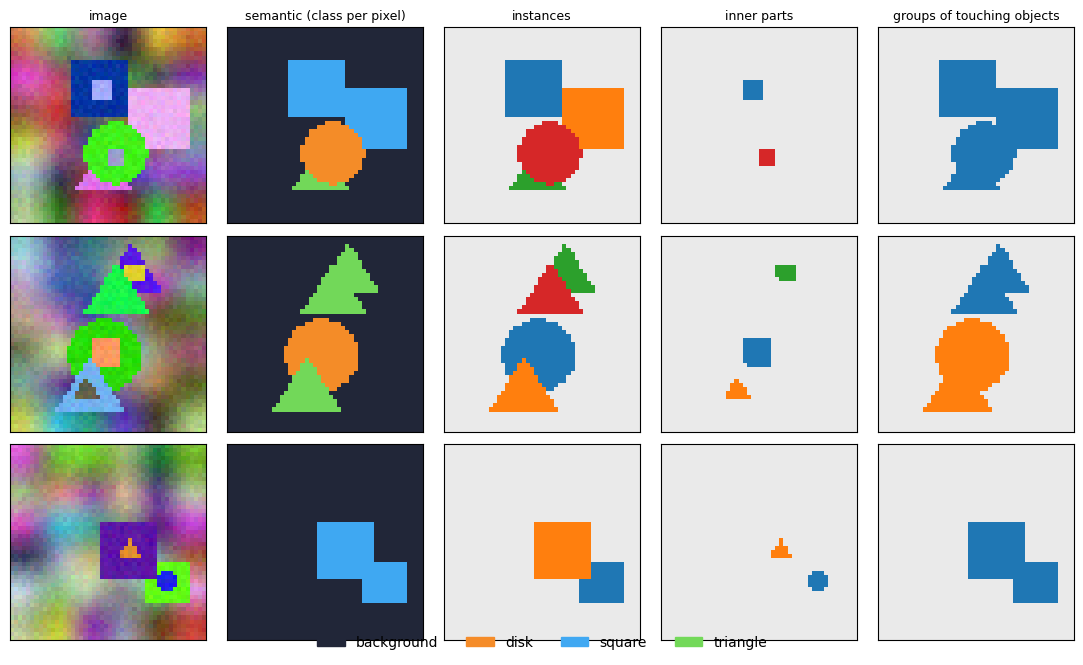

In [4]:
INST_COLORS = np.array(plt.get_cmap('tab10').colors)

def to_img(x):
    """(3,H,W) tensor -> (H,W,3) numpy for imshow."""
    return x.detach().cpu().numpy().transpose(1, 2, 0)

def sem_rgb(sem):
    return CLASS_COLORS[np.asarray(sem)]

def ids_rgb(ids):
    """Colour an id map (instances, parts or groups); 0 is light grey."""
    ids = np.asarray(ids); out = np.full(ids.shape + (3,), 0.92)
    for k in range(1, int(ids.max()) + 1):
        out[ids == k] = INST_COLORS[(k - 1) % 10]
    return out

def overlay(img, mask, color=(1.0, 0.15, 0.15), alpha=0.55):
    """Tint the pixels of a boolean mask."""
    out = np.array(img, dtype=np.float32).copy(); m = np.asarray(mask) > 0
    out[m] = (1 - alpha) * out[m] + alpha * np.array(color, dtype=np.float32)
    return out

def draw_points(ax, pts, labels):
    """Green star = foreground click, red star = background click; padding points (label -1) are skipped."""
    for (x, y), l in zip(np.asarray(pts), np.asarray(labels)):
        if l >= 0:
            ax.plot(x, y, marker='*', ms=13, color='lime' if l == 1 else 'red', mec='k', ls='none')

fig, axes = plt.subplots(3, 5, figsize=(11, 6.6))
for r in range(3):
    i = r + 1
    axes[r, 0].imshow(to_img(Xva[i])); axes[r, 1].imshow(sem_rgb(Sva[i]))
    axes[r, 2].imshow(ids_rgb(Iva[i])); axes[r, 3].imshow(ids_rgb(Pva[i])); axes[r, 4].imshow(ids_rgb(Gva[i]))
for ax, t in zip(axes[0], ['image', 'semantic (class per pixel)', 'instances', 'inner parts', 'groups of touching objects']):
    ax.set_title(t, fontsize=9)
clear_axes(axes)
handles = [mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c]) for c in range(NUM_CLASSES)]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(); plt.show()

### The metric: mean IoU

Pixel accuracy is dominated by the background, so every semantic result below is a **mean intersection over union** over the four classes, computed from a confusion matrix exactly as in the Week 6 notebook. The `evaluate_semantic` helper takes any function that maps a batch of images on `device` to integer labels, so SETR, SegFormer and MaskFormer are all scored by the same code.

In [5]:
def confusion_matrix(pred, gt, n):
    """(n, n) confusion matrix via bincount; pred and gt are integer label tensors of any matching shape."""
    k = gt.reshape(-1) * n + pred.reshape(-1)
    return torch.bincount(k, minlength=n * n).reshape(n, n).float()

def mean_iou(cm):
    inter = cm.diag(); union = cm.sum(0) + cm.sum(1) - inter
    return (inter / union.clamp(min=1e-6))[union > 0].mean().item()

@torch.no_grad()
def evaluate_semantic(predict, X, S, bs=64):
    """predict: images on `device` -> integer labels (B,H,W). Returns (mIoU, confusion matrix)."""
    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES)
    for i in range(0, len(X), bs):
        p = predict(X[i:i + bs].to(device)).detach().cpu()
        cm += confusion_matrix(p, S[i:i + bs], NUM_CLASSES)
    return mean_iou(cm), cm

RESULTS = {}                                                   # name -> (val mIoU, params, training seconds)
allbg = torch.zeros_like(Sva)
print(f'"all background" baseline: pixel accuracy {(allbg == Sva).float().mean():.3f}, '
      f'mean IoU {mean_iou(confusion_matrix(allbg, Sva, NUM_CLASSES)):.3f}')

"all background" baseline: pixel accuracy 0.823, mean IoU 0.206


## 1. SETR: segmentation as sequence-to-sequence prediction

*Zheng et al., CVPR 2021* ("Rethinking semantic segmentation from a sequence-to-sequence perspective with transformers"). The slide summarises the step from DETR to SETR in one line:

> "SETR replaces stacked convolution layer-based encoder with a pure Transformer which gradually reduces spatial resolution."

The relative clause belongs to the convolutional encoder in the paper's wording: it is the CNN that gradually reduces spatial resolution as it goes deeper, and the Transformer that replaces it; a ViT encoder keeps the whole stack at one token resolution and models global context from the first layer. SETR treats segmentation as **sequence-to-sequence prediction**:

1. cut the image into patches ($16 \times 16$ in the paper, $4 \times 4$ here) and embed each one linearly, giving a sequence $E = [e_1, \dots, e_N]$;
2. add a learned positional embedding and apply $L$ standard Transformer layers, each $Z' = \mathrm{MSA}(\mathrm{LN}(Z)) + Z$ followed by $Z = \mathrm{MLP}(\mathrm{LN}(Z')) + Z'$;
3. reshape the $N$ output tokens into an $\frac{H}{p} \times \frac{W}{p}$ feature map and decode it to per-pixel class scores.

The slide's figure has three parts: (a) the encoder, a standard Transformer; (b) **SETR-PUP**, a progressive up-sampling decoder that alternates a convolution with a $2\times$ bilinear upsampling until the input resolution is reached; (c) **SETR-MLA**, multi-level feature aggregation, which takes the tokens of several layers, projects each, upsamples and concatenates them. We build the attention first and check it, then the encoder and both decoders, and train both.

### 1a. Attention from scratch, checked against PyTorch

Every model in this notebook uses one `attention` function and one `MHA` module. Self-attention (queries, keys and values from the same tokens) and cross-attention (queries from one sequence, keys and values from another) are the same code with different inputs, and an optional boolean `keep` mask decides which keys each query may look at, which section 4 needs. We check the module against `nn.MultiheadAttention` with copied weights, and the core against `F.scaled_dot_product_attention`.

In [6]:
def attention(q, k, v, keep=None):
    """Scaled dot-product attention. q: (B,h,Nq,d), k and v: (B,h,Nk,d). keep: optional boolean mask
    broadcastable to (B,h,Nq,Nk), True where a query may attend. Returns (output, attention weights)."""
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    if keep is not None:
        scores = scores.masked_fill(~keep, float('-inf'))
    w = scores.softmax(dim=-1)
    return w @ v, w

class MHA(nn.Module):
    """Multi-head attention with separate q / k / v projections, so it serves self- and cross-attention."""
    def __init__(self, dim, heads):
        super().__init__()
        self.h, self.d = heads, dim // heads
        self.q, self.k, self.v, self.o = (nn.Linear(dim, dim) for _ in range(4))
        self.last_attn = None                       # (B, h, Nq, Nk) of the last call, for the viewers below
    def forward(self, xq, xkv, keep=None):
        B, Nq, C = xq.shape; Nk = xkv.shape[1]
        q = self.q(xq).reshape(B, Nq, self.h, self.d).transpose(1, 2)
        k = self.k(xkv).reshape(B, Nk, self.h, self.d).transpose(1, 2)
        v = self.v(xkv).reshape(B, Nk, self.h, self.d).transpose(1, 2)
        out, w = attention(q, k, v, keep)
        self.last_attn = w.detach()
        return self.o(out.transpose(1, 2).reshape(B, Nq, C))

def copy_into_torch_mha(mha, ref):
    """Load our MHA's weights into an nn.MultiheadAttention so the two compute the same function."""
    with torch.no_grad():
        ref.in_proj_weight.copy_(torch.cat([mha.q.weight, mha.k.weight, mha.v.weight]))
        ref.in_proj_bias.copy_(torch.cat([mha.q.bias, mha.k.bias, mha.v.bias]))
        ref.out_proj.weight.copy_(mha.o.weight); ref.out_proj.bias.copy_(mha.o.bias)

set_seed(0)
dim, heads, B, N = 64, 4, 2, 12
mha = MHA(dim, heads).to(device)
ref = nn.MultiheadAttention(dim, heads, batch_first=True).to(device)
copy_into_torch_mha(mha, ref)
x = torch.randn(B, N, dim, device=device)
out_scratch = mha(x, x)
out_ref, w_ref = ref(x, x, x, average_attn_weights=True)
assert torch.allclose(out_scratch, out_ref, atol=1e-5)
assert torch.allclose(mha.last_attn.mean(1), w_ref, atol=1e-5)
print(f'MHA vs nn.MultiheadAttention: max |diff| outputs {(out_scratch - out_ref).abs().max():.2e}, '
      f'weights {(mha.last_attn.mean(1) - w_ref).abs().max():.2e}')

q, k, v = (torch.randn(B, heads, N, dim // heads, device=device) for _ in range(3))
o1, _ = attention(q, k, v)
o2 = F.scaled_dot_product_attention(q, k, v)
assert torch.allclose(o1, o2, atol=1e-5)
print(f'attention() vs F.scaled_dot_product_attention: max |diff| {(o1 - o2).abs().max():.2e}')
print(f'the attention weights of every query sum to one: {mha.last_attn.sum(-1).mean():.4f}')

MHA vs nn.MultiheadAttention: max |diff| outputs 8.94e-08, weights 2.98e-08
attention() vs F.scaled_dot_product_attention: max |diff| 2.38e-07
the attention weights of every query sum to one: 1.0000


### 1b. The ViT encoder

A strided convolution with kernel and stride equal to the patch size is exactly the linear patch embedding: it multiplies each $4 \times 4 \times 3$ patch by the same matrix. A learned positional embedding is added, and pre-norm Transformer blocks follow. The encoder returns the tokens of every layer (MLA needs them) and the token grid size (the decoders need it). If an image of a different size arrives, the positional embedding is bilinearly interpolated to the new grid, the standard trick for running a ViT at a new resolution; section 2 tests how well that works.

In [7]:
class Block(nn.Module):
    """Pre-norm Transformer encoder block: x + MHA(LN(x)), then x + MLP(LN(x))."""
    def __init__(self, dim, heads, mlp_ratio=2):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.attn = MHA(dim, heads)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_ratio * dim), nn.GELU(), nn.Linear(mlp_ratio * dim, dim))
    def forward(self, x, keep=None):
        h = self.ln1(x)
        x = x + self.attn(h, h, keep)
        return x + self.mlp(self.ln2(x))

class ViTEncoder(nn.Module):
    """Patchify with a strided conv, add a learned positional embedding, run `depth` blocks.
    Returns (normalised tokens (B,N,dim), the list of per-layer tokens, the token grid (h, w))."""
    def __init__(self, dim=64, depth=3, heads=4, patch=PATCH, img=IMG):
        super().__init__()
        self.patch = nn.Conv2d(3, dim, patch, stride=patch)
        self.grid = img // patch
        self.pos = nn.Parameter(torch.zeros(1, self.grid * self.grid, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        self.blocks = nn.ModuleList([Block(dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        t = self.patch(x)                                   # (B, dim, h, w)
        h, w = t.shape[-2:]
        t = t.flatten(2).transpose(1, 2)                    # (B, N, dim): the sequence
        pos = self.pos
        if (h, w) != (self.grid, self.grid):                # another resolution: interpolate the positional embedding
            pos = self.pos.transpose(1, 2).reshape(1, -1, self.grid, self.grid)
            pos = F.interpolate(pos, size=(h, w), mode='bilinear', align_corners=False).flatten(2).transpose(1, 2)
        t = t + pos
        feats = []
        for blk in self.blocks:
            t = blk(t); feats.append(t)
        return self.norm(t), feats, (h, w)

set_seed(0)
enc = ViTEncoder().to(device)
tokens, feats, hw = enc(Xva[:2].to(device))
print(f'image {tuple(Xva[:2].shape)} -> {hw[0]} x {hw[1]} = {tokens.shape[1]} tokens of dim {tokens.shape[2]}: {tuple(tokens.shape)}')
print(f'{len(feats)} layers, attention matrix per head {tuple(enc.blocks[0].attn.last_attn.shape[-2:])}, '
      f'encoder params {count_params(enc):,}')

image (2, 3, 48, 48) -> 12 x 12 = 144 tokens of dim 64: (2, 144, 64)
3 layers, attention matrix per head (144, 144), encoder params 112,896


### 1c. Two decoders: PUP and MLA

The decoder's only job is to turn the $12 \times 12 \times C$ token map into $48 \times 48 \times (K{+}1)$ class scores. SETR-PUP does it progressively: a $3 \times 3$ convolution, then a $2\times$ bilinear upsampling, repeated until the input resolution is reached (four rounds in the paper for stride 16, two rounds here for stride 4). SETR-MLA instead aggregates several layers: each layer's tokens get their own convolutional projection, are upsampled to full resolution and concatenated before the final classifier. Both end with a convolution to $K{+}1$ channels, the per-pixel classifier that Week 6 introduced.

In [8]:
class PUPDecoder(nn.Module):
    """Progressive UPsampling: (conv 3x3, BN, ReLU, 2x bilinear) repeated `n_up` times, then 1x1 conv to classes."""
    def __init__(self, dim, n_classes, n_up=2, hidden=64):
        super().__init__()
        layers, c = [], dim
        for _ in range(n_up):
            layers += [nn.Conv2d(c, hidden, 3, padding=1), nn.BatchNorm2d(hidden), nn.ReLU(inplace=True),
                       nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)]
            c = hidden
        self.net = nn.Sequential(*layers)
        self.cls = nn.Conv2d(hidden, n_classes, 1)
    def forward(self, tokens, hw):
        B, N, C = tokens.shape
        x = tokens.transpose(1, 2).reshape(B, C, hw[0], hw[1]).contiguous()   # sequence -> 2D map (contiguous: BatchNorm's backward on Apple's mps needs it)
        return self.cls(self.net(x))

class MLADecoder(nn.Module):
    """Multi-Level feature Aggregation: project the tokens of the last `n_levels` layers, upsample each to full
    resolution, concatenate, classify."""
    def __init__(self, dim, n_classes, n_levels=3, hidden=32):
        super().__init__()
        self.n_levels = n_levels
        self.proj = nn.ModuleList([nn.Sequential(nn.Conv2d(dim, hidden, 1), nn.ReLU(inplace=True),
                                                 nn.Conv2d(hidden, hidden, 3, padding=1), nn.ReLU(inplace=True))
                                   for _ in range(n_levels)])
        self.cls = nn.Conv2d(hidden * n_levels, n_classes, 1)
    def forward(self, feats, hw):
        outs = []
        for f, p in zip(feats[-self.n_levels:], self.proj):
            B, N, C = f.shape
            x = p(f.transpose(1, 2).reshape(B, C, hw[0], hw[1]))
            outs.append(F.interpolate(x, scale_factor=PATCH, mode='bilinear', align_corners=False))
        return self.cls(torch.cat(outs, 1))

class SETR(nn.Module):
    """ViT encoder + PUP or MLA decoder = per-pixel class scores at input resolution."""
    def __init__(self, decoder='pup', dim=64, depth=3, heads=4):
        super().__init__()
        self.kind = decoder
        self.encoder = ViTEncoder(dim, depth, heads)
        self.decoder = PUPDecoder(dim, NUM_CLASSES) if decoder == 'pup' else MLADecoder(dim, NUM_CLASSES, n_levels=depth)
    def forward(self, x):
        t, feats, hw = self.encoder(x)
        return self.decoder(t, hw) if self.kind == 'pup' else self.decoder(feats, hw)

set_seed(0); setr_pup = SETR('pup').to(device)
set_seed(0); setr_mla = SETR('mla').to(device)
x = Xva[:2].to(device)
print(f'SETR-PUP: {tuple(x.shape)} -> {tuple(setr_pup(x).shape)}   params {count_params(setr_pup):,}')
print(f'SETR-MLA: {tuple(x.shape)} -> {tuple(setr_mla(x).shape)}   params {count_params(setr_mla):,}')
print('both share the encoder design; the encoder alone has', f'{count_params(setr_pup.encoder):,}', 'params')

SETR-PUP: (2, 3, 48, 48) -> (2, 4, 48, 48)   params 187,268
SETR-MLA: (2, 3, 48, 48) -> (2, 4, 48, 48)   params 147,268
both share the encoder design; the encoder alone has 112,896 params


### 1d. Training both variants

The recipe is the same for every per-pixel model in this notebook: pixel-wise cross-entropy, AdamW at learning rate $2 \times 10^{-3}$ with a short warm-up and cosine decay, batches of 32 images, 300 steps (about 19 epochs of the 512 training images). The loop prints the validation mIoU every 50 steps and the elapsed seconds.

In [9]:
def make_scheduler(opt, steps, warm=30):
    def f(s):
        if s < warm:
            return (s + 1) / warm
        return 0.5 * (1 + math.cos(math.pi * (s - warm) / max(1, steps - warm)))
    return torch.optim.lr_scheduler.LambdaLR(opt, f)

def train_semantic(model, steps=300, bs=32, lr=2e-3, log_every=50):
    """Pixel-wise cross-entropy training. Returns the (step, val mIoU) curve and the elapsed seconds."""
    model.to(device).train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = make_scheduler(opt, steps)
    gen = torch.Generator().manual_seed(0)
    curve, t0 = [], time.time()
    for s in range(1, steps + 1):
        idx = torch.randint(0, len(Xtr), (bs,), generator=gen)
        logits = model(Xtr[idx].to(device))
        loss = F.cross_entropy(logits, Str[idx].to(device))
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        if s % log_every == 0 or s == steps:
            model.eval()
            miou, _ = evaluate_semantic(lambda z: model(z).argmax(1), Xva, Sva)
            model.train(); curve.append((s, miou))
            print(f'  step {s:4d}  loss {loss.item():.3f}  val mIoU {miou:.3f}  ({time.time() - t0:.1f}s)')
    model.eval()
    return curve, time.time() - t0

print('SETR-PUP')
set_seed(0); setr_pup = SETR('pup')
curve_pup, t_pup = train_semantic(setr_pup)
RESULTS['SETR-PUP'] = (curve_pup[-1][1], count_params(setr_pup), t_pup)
print('SETR-MLA')
set_seed(0); setr_mla = SETR('mla')
curve_mla, t_mla = train_semantic(setr_mla)
RESULTS['SETR-MLA'] = (curve_mla[-1][1], count_params(setr_mla), t_mla)

SETR-PUP


  step   50  loss 0.358  val mIoU 0.208  (3.0s)


  step  100  loss 0.284  val mIoU 0.338  (6.0s)


  step  150  loss 0.218  val mIoU 0.432  (9.0s)


  step  200  loss 0.181  val mIoU 0.531  (12.1s)


...

  step  100  loss 0.556  val mIoU 0.206  (5.6s)


  step  150  loss 0.374  val mIoU 0.294  (8.5s)


  step  200  loss 0.334  val mIoU 0.340  (11.3s)


  step  250  loss 0.299  val mIoU 0.348  (14.1s)


  step  300  loss 0.326  val mIoU 0.364  (17.0s)


Both decoders learn the task from a pure Transformer encoder that never downsampled below the $12 \times 12$ token grid; the figure shows what a stride-4 token map can and cannot express. Boundaries are decided at patch resolution and then smoothed by the upsampling, so the thin edges of the triangles are where the errors sit.

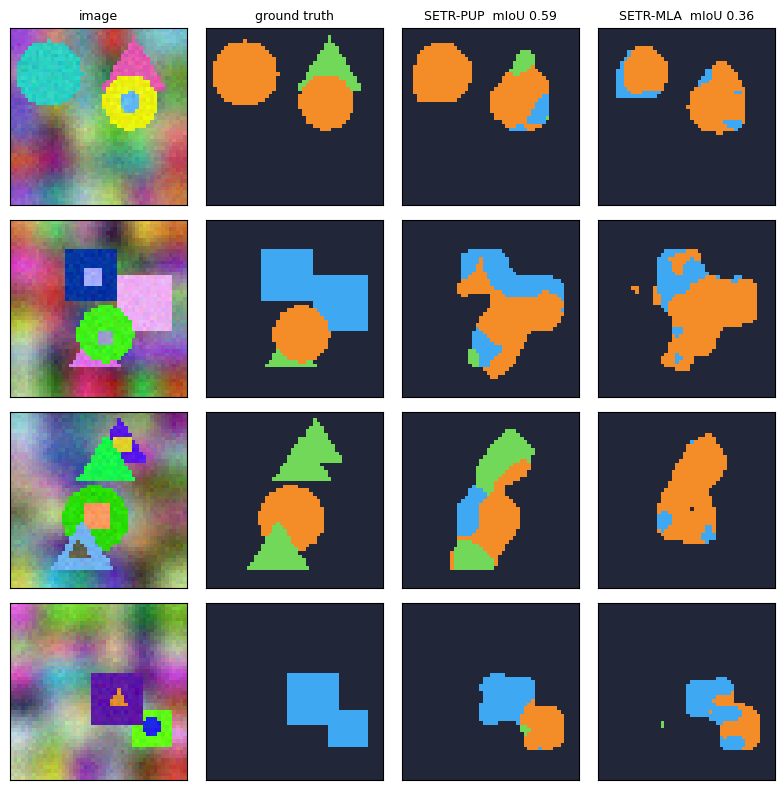

In [10]:
with torch.no_grad():
    pred_pup = setr_pup(Xva[:4].to(device)).argmax(1).cpu().numpy()
    pred_mla = setr_mla(Xva[:4].to(device)).argmax(1).cpu().numpy()
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for r in range(4):
    axes[r, 0].imshow(to_img(Xva[r])); axes[r, 1].imshow(sem_rgb(Sva[r]))
    axes[r, 2].imshow(sem_rgb(pred_pup[r])); axes[r, 3].imshow(sem_rgb(pred_mla[r]))
for ax, t in zip(axes[0], ['image', 'ground truth', f'SETR-PUP  mIoU {RESULTS["SETR-PUP"][0]:.2f}',
                           f'SETR-MLA  mIoU {RESULTS["SETR-MLA"][0]:.2f}']):
    ax.set_title(t, fontsize=9)
clear_axes(axes); plt.tight_layout(); plt.show()

### Widget 1: what does a patch attend to?

A ViT encoder has global context at every layer: any patch may attend to any other. The maps below are the attention weights of one query patch (outlined in white) over all 144 patches, averaged over heads, for the trained SETR-PUP encoder. Drag `row` and `col` onto a shape and then onto the background, step through `layer`, and see whether the pattern changes with depth: whether the early layers spread attention over patches that merely look alike and the last layer concentrates on the object the query belongs to, which is what would let a patch on a triangle's corner be labelled "triangle". The printout under the figure measures one version of that question for the four queries shown: the fraction of the attention mass that lands on patches of the query's own semantic class, at the first and at the last layer, next to the fraction of all patches that class covers (what a uniform attention would score).

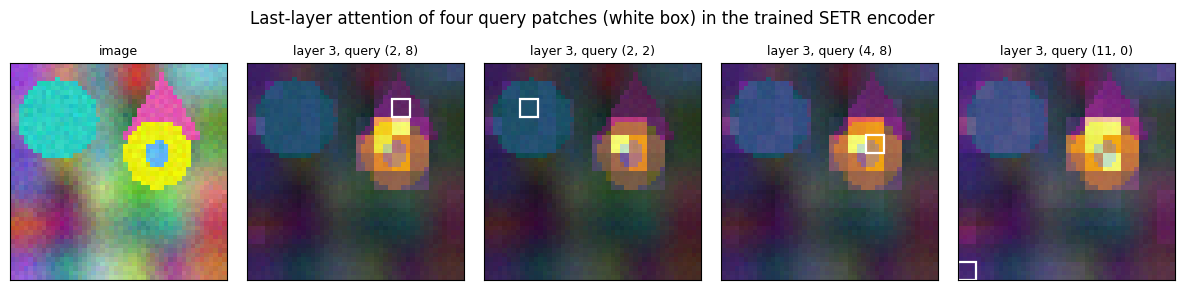

query (2, 8) on "triangle  ": attention on own-class patches 4% at layer 1, 4% at layer 3  (that class covers 3% of the patches)
query (2, 2) on "disk      ": attention on own-class patches 17% at layer 1, 60% at layer 3  (that class covers 18% of the patches)
query (4, 8) on "disk      ": attention on own-class patches 17% at layer 1, 49% at layer 3  (that class covers 18% of the patches)
query (11, 0) on "background": attention on own-class patches 78% at layer 1, 50% at layer 3  (that class covers 78% of the patches)


In [11]:
DEMO_ATT = next(i for i in range(len(Iva)) if Iva[i].max() >= 3)          # a validation image with three objects
with torch.no_grad():
    setr_pup.encoder(Xva[DEMO_ATT:DEMO_ATT + 1].to(device))
ATT = np.stack([blk.attn.last_attn[0].mean(0).cpu().numpy() for blk in setr_pup.encoder.blocks])   # (L, N, N)
att_img = to_img(Xva[DEMO_ATT])
inst_att = Iva[DEMO_ATT].numpy()
queries = []
for k in range(1, 4):                                                       # one query patch per object, at its centroid
    ys, xs = np.nonzero(inst_att == k)
    queries.append((int(ys.mean()) // PATCH, int(xs.mean()) // PATCH))
d_bg = ndi.distance_transform_edt(inst_att == 0)                            # and one background patch far from every object
r_bg, c_bg = np.unravel_index(int(d_bg.argmax()), d_bg.shape)
queries.append((int(r_bg) // PATCH, int(c_bg) // PATCH))

def show_attention(ax, layer, row, col, title=None):
    a = ATT[layer, row * GRID + col].reshape(GRID, GRID)
    ax.imshow(att_img)
    ax.imshow(np.kron(a, np.ones((PATCH, PATCH))), cmap='inferno', alpha=0.65, vmin=0, vmax=a.max())
    ax.add_patch(mpatches.Rectangle((col * PATCH - 0.5, row * PATCH - 0.5), PATCH, PATCH, fill=False, ec='white', lw=1.6))
    ax.set_title(title or f'layer {layer + 1}, query ({row}, {col})', fontsize=9)

fig, axes = plt.subplots(1, 5, figsize=(12, 2.8))
axes[0].imshow(att_img); axes[0].set_title('image', fontsize=9)
for ax, (r, c) in zip(axes[1:], queries):
    show_attention(ax, len(ATT) - 1, r, c)
clear_axes(axes); plt.suptitle('Last-layer attention of four query patches (white box) in the trained SETR encoder', y=1.02)
plt.tight_layout(); plt.show()

# measured, not assumed: how much of a query's attention lands on patches of its own class?
sem_patch = Sva[DEMO_ATT].view(GRID, PATCH, GRID, PATCH).permute(0, 2, 1, 3).reshape(GRID * GRID, -1).mode(1).values   # majority class per patch

def own_class_mass(layer, row, col):
    """Fraction of one query's attention (layer index from 0) on patches whose majority class is the query's own."""
    q = row * GRID + col
    return float(ATT[layer, q][(sem_patch == sem_patch[q]).numpy()].sum())

for r, c in queries:
    own = (sem_patch == sem_patch[r * GRID + c]).float().mean()
    print(f'query ({r}, {c}) on "{CLASS_NAMES[int(sem_patch[r * GRID + c])]:10s}": attention on own-class patches '
          f'{own_class_mass(0, r, c):.0%} at layer 1, {own_class_mass(len(ATT) - 1, r, c):.0%} at layer {len(ATT)}  '
          f'(that class covers {own:.0%} of the patches)')

The printed measurement answers the question for this image. The two disk queries start near uniform, with 16% of their attention on disk patches at layer 1 (disks cover 18% of the image), and end with 59% and 49% at layer 3; the triangle query, whose patch holds only a corner of a small object (3% of the image), never concentrates; and the background query moves half of its attention off the background by the last layer. So the last layer does pull the patches of an object together, and lets background patches look at the objects, which is the global context the slide promises, with the caveat that a 300-step, 64-dimensional encoder does it for the large objects and not for the small ones.

Now the same thing under your control. Drag `row` and `col` onto a shape and then onto the background, and step through `layer`; the right panel is the raw $12 \times 12$ weight map of that query.

In [12]:
def attention_viewer(layer=3, row=queries[0][0], col=queries[0][1]):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(att_img); axes[0].set_title('image', fontsize=9)
    axes[0].add_patch(mpatches.Rectangle((col * PATCH - 0.5, row * PATCH - 0.5), PATCH, PATCH, fill=False, ec='white', lw=1.6))
    show_attention(axes[1], layer - 1, row, col)
    a = ATT[layer - 1, row * GRID + col].reshape(GRID, GRID)
    axes[2].imshow(a, cmap='inferno'); axes[2].set_title(f'12 x 12 weights, max {a.max():.2f}', fontsize=9)
    clear_axes(axes); plt.tight_layout(); plt.show()

interact(attention_viewer,
         layer=IntSlider(min=1, max=len(ATT), step=1, value=len(ATT), continuous_update=False),
         row=IntSlider(min=0, max=GRID - 1, step=1, value=queries[0][0], continuous_update=False),
         col=IntSlider(min=0, max=GRID - 1, step=1, value=queries[0][1], continuous_update=False));

interactive(children=(IntSlider(value=3, continuous_update=False, description='layer', max=3, min=1), IntSlide…

## 2. SegFormer: hierarchical features, efficient attention and an all-MLP decoder

*Xie et al., NeurIPS 2021*. The slide lists what changes relative to SETR:

> "Uses a hierarchical Transformer encoder for feature extraction and a lightweight MLP decoder for predicting the final mask."
> "Uses a patch size of 4 × 4 in contrast to ViT which uses a patch size of 16 × 16."
> "Has an overlapped patch merging process to maintain local continuity around patches."
> "Introduces Positional-Encoding-Free design as a key feature."

A patch size of 4 at the first stage means sixteen times more tokens than a ViT at the same image size, so the encoder cannot afford plain $O(N^2)$ attention there. The paper's answer is **efficient self-attention** with a **sequence reduction ratio**. We build the four ingredients in order, check the attention against section 1, and measure what the reduction buys.

### 2a. Overlapped patch merging

A ViT's patch embedding is a convolution whose kernel equals its stride, so neighbouring patches share no pixels. SegFormer's merging convolution has a kernel **larger** than its stride ($7 \times 7$ with stride 4, then $3 \times 3$ with stride 2): each token sees a little of its neighbours' territory, which is the "local continuity around patches" of the slide. Applied three times, it produces feature maps at strides 4, 8 and 16 with growing channel counts, the hierarchy a CNN backbone would give.

### 2b. Efficient self-attention with sequence reduction

Standard attention over $N$ tokens costs $O(N^2)$. SegFormer keeps all $N$ queries but shrinks the keys and values: the token map is reshaped and projected so that $K$ and $V$ have $N / R^2$ rows,
$$\hat K = \mathrm{Reshape}\!\left(\tfrac{N}{R^2},\; C \cdot R^2\right)(K), \qquad K = \mathrm{Linear}(C \cdot R^2,\, C)(\hat K),$$
which is a convolution with kernel and stride $R$ over the 2D token map (the paper calls the total reduction of the sequence length the reduction ratio; we use $R$ for the per-side factor, so the paper's $R$ is our $R^2$). The attention matrix is then $N \times N/R^2$ and the cost is $O(N^2 / R^2)$. With $R = 1$ this must be ordinary attention, and we assert that it is.

In [13]:
class OverlapPatchMerging(nn.Module):
    """A strided conv with a kernel larger than its stride: neighbouring patches overlap, so local continuity
    survives. Returns tokens (B, N, C) plus the token grid (h, w)."""
    def __init__(self, cin, cout, k, stride):
        super().__init__()
        self.proj = nn.Conv2d(cin, cout, k, stride=stride, padding=k // 2)
        self.norm = nn.LayerNorm(cout)
    def forward(self, x):
        x = self.proj(x)
        h, w = x.shape[-2:]
        return self.norm(x.flatten(2).transpose(1, 2)), h, w

class EfficientAttention(nn.Module):
    """Self-attention whose keys and values come from a sequence reduced R x R by a strided conv,
    so the attention matrix is N x N/R^2 instead of N x N."""
    def __init__(self, dim, heads, R):
        super().__init__()
        self.h, self.d, self.R = heads, dim // heads, R
        self.q, self.kv, self.o = nn.Linear(dim, dim), nn.Linear(dim, 2 * dim), nn.Linear(dim, dim)
        if R > 1:
            self.sr = nn.Conv2d(dim, dim, R, stride=R)      # the Reshape + Linear of the paper, as one conv
            self.sr_norm = nn.LayerNorm(dim)
        self.last_attn = None
    def forward(self, x, h, w):
        B, N, C = x.shape
        q = self.q(x).reshape(B, N, self.h, self.d).transpose(1, 2)
        if self.R > 1:
            x = self.sr(x.transpose(1, 2).reshape(B, C, h, w)).flatten(2).transpose(1, 2)
            x = self.sr_norm(x)                               # (B, N / R^2, C)
        k, v = self.kv(x).reshape(B, -1, 2, self.h, self.d).permute(2, 0, 3, 1, 4)
        out, wts = attention(q, k, v)
        self.last_attn = wts.detach()
        return self.o(out.transpose(1, 2).reshape(B, N, C))

set_seed(0)
dim, heads = 64, 4
ea = EfficientAttention(dim, heads, R=1).to(device)
ref = MHA(dim, heads).to(device)
with torch.no_grad():                                          # same weights in both modules
    ref.q.weight.copy_(ea.q.weight); ref.q.bias.copy_(ea.q.bias)
    ref.k.weight.copy_(ea.kv.weight[:dim]); ref.k.bias.copy_(ea.kv.bias[:dim])
    ref.v.weight.copy_(ea.kv.weight[dim:]); ref.v.bias.copy_(ea.kv.bias[dim:])
    ref.o.weight.copy_(ea.o.weight); ref.o.bias.copy_(ea.o.bias)
x = torch.randn(2, GRID * GRID, dim, device=device)
a, b = ea(x, GRID, GRID), ref(x, x)
assert torch.allclose(a, b, atol=1e-5)
print(f'EfficientAttention(R=1) == standard attention: max |diff| {(a - b).abs().max():.2e}, '
      f'attention matrix {tuple(ea.last_attn.shape[-2:])}')
for R in (2, 3):
    e = EfficientAttention(dim, heads, R=R).to(device); e(x, GRID, GRID)
    print(f'R = {R}: {GRID * GRID} queries attend to {ea.last_attn.shape[-1] // (R * R)} keys, '
          f'attention matrix {tuple(e.last_attn.shape[-2:])}')

EfficientAttention(R=1) == standard attention: max |diff| 0.00e+00, attention matrix (144, 144)
R = 2: 144 queries attend to 36 keys, attention matrix (144, 36)
R = 3: 144 queries attend to 16 keys, attention matrix (144, 16)


### 2c. The cost of attention, measured

The claim is that the reduction turns an $N \times N$ matrix into $N \times N/R^2$. The multiply-adds of $QK^\top$ and of $AV$ are each $N \cdot N_k \cdot d$, and the matrix itself holds $N \cdot N_k$ floats. For a $256 \times 256$ image with $4 \times 4$ patches, $N = 4096$ and the full matrix has 16.8 million entries per head; with $R = 8$ (the paper's stage-1 ratio of 64) the keys drop to 64. We compute the counts and time the attention core on this machine for four image sizes and four ratios, then plot them.

In [14]:
def attention_cost(N, d, R):
    """Multiply-adds of QK^T plus AV, and the size of the attention matrix in floats, for N queries and N/R^2 keys."""
    Nk = N // (R * R)
    return 2 * N * Nk * d, N * Nk

@torch.no_grad()
def time_attention(N, d, R, repeats=3):
    q = torch.randn(1, 1, N, d, device=device); kv = torch.randn(1, 1, N // (R * R), d, device=device)
    best = float('inf')
    for _ in range(repeats):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter(); attention(q, kv, kv)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        best = min(best, time.perf_counter() - t0)
    return best

SIDES, RS, D_HEAD = [64, 128, 192, 256], [1, 2, 4, 8], 64
COST = {}
for side in SIDES:
    N = (side // PATCH) ** 2
    for R in RS:
        madds, floats = attention_cost(N, D_HEAD, R)
        COST[(side, R)] = (madds, floats, time_attention(N, D_HEAD, R))
print(f'image 256 x 256, patch 4: N = {(256 // PATCH) ** 2} tokens, head dim {D_HEAD}')
print(f'{"R":>3} {"keys":>6} {"multiply-adds":>15} {"matrix floats":>14} {"time (ms)":>10}')
for R in RS:
    madds, floats, sec = COST[(256, R)]
    print(f'{R:>3} {4096 // (R * R):>6} {madds:>15,} {floats:>14,} {1000 * sec:>10.2f}')
speed = COST[(256, 1)][2] / COST[(256, 8)][2]
print(f'\nR = 8 is {COST[(256, 1)][0] / COST[(256, 8)][0]:.0f}x fewer multiply-adds and {speed:.1f}x faster here')

image 256 x 256, patch 4: N = 4096 tokens, head dim 64
  R   keys   multiply-adds  matrix floats  time (ms)
  1   4096   2,147,483,648     16,777,216       7.42
  2   1024     536,870,912      4,194,304       1.82
  4    256     134,217,728      1,048,576       0.50
  8     64      33,554,432        262,144       0.16

R = 8 is 64x fewer multiply-adds and 46.1x faster here


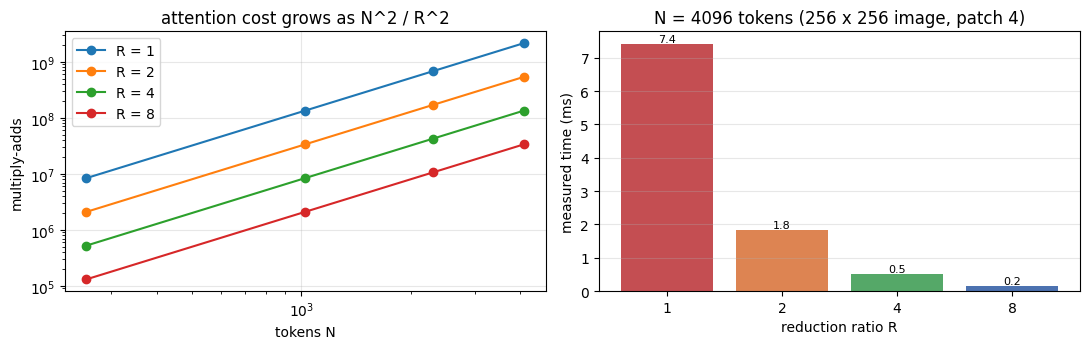

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
Ns = [(s // PATCH) ** 2 for s in SIDES]
for R in RS:
    axes[0].plot(Ns, [COST[(s, R)][0] for s in SIDES], 'o-', label=f'R = {R}')
axes[0].set_xscale('log'); axes[0].set_yscale('log'); axes[0].set_xlabel('tokens N'); axes[0].set_ylabel('multiply-adds')
axes[0].set_title('attention cost grows as N^2 / R^2'); axes[0].legend(); axes[0].grid(alpha=0.3)
ms = [1000 * COST[(256, R)][2] for R in RS]
axes[1].bar([str(R) for R in RS], ms, color=['#c44e52', '#dd8452', '#55a868', '#4c72b0'])
for i, v in enumerate(ms):
    axes[1].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=8)
axes[1].set_xlabel('reduction ratio R'); axes[1].set_ylabel('measured time (ms)')
axes[1].set_title('N = 4096 tokens (256 x 256 image, patch 4)'); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Widget 2: sequence reduction versus cost

Choose the image side and the reduction ratio. The printout gives the number of keys, the multiply-adds, the memory of one head's attention matrix and the time measured above; the bars compare the four ratios at that image size. Push `side` to 256 and `R` to 1 to see why a stage-1 SegFormer block cannot use plain attention, then drag `R` up and watch the matrix shrink by $R^2$.

In [16]:
def reduction_explorer(side=256, R=1):
    N = (side // PATCH) ** 2
    madds, floats, sec = COST[(side, R)]
    print(f'{side} x {side} image, patch {PATCH}: N = {N} queries, N / R^2 = {N // (R * R)} keys')
    print(f'  multiply-adds {madds:,}   attention matrix {floats:,} floats = {4 * floats / 2 ** 20:.1f} MB per head   '
          f'measured {1000 * sec:.2f} ms')
    fig, ax = plt.subplots(figsize=(5.5, 3))
    vals = [COST[(side, r)][0] for r in RS]
    ax.bar([f'R = {r}' for r in RS], vals, color=['#4c72b0' if r != R else '#c44e52' for r in RS])
    ax.set_yscale('log'); ax.set_ylabel('multiply-adds (log)'); ax.set_title(f'attention cost at N = {N}'); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()

interact(reduction_explorer, side=Dropdown(options=SIDES, value=256), R=Dropdown(options=RS, value=1));

interactive(children=(Dropdown(description='side', index=3, options=(64, 128, 192, 256), value=256), Dropdown(…

### 2d. Mix-FFN: why no positional encoding is needed

A ViT adds a positional embedding because attention and an MLP are permutation-equivariant: shuffle the tokens and the outputs shuffle the same way, so nothing knows where a token is. SegFormer's **Mix-FFN** puts a $3 \times 3$ depth-wise convolution between the two linear layers of the feed-forward block,
$$x_{out} = \mathrm{MLP}\big(\mathrm{GELU}(\mathrm{Conv}_{3\times3}(\mathrm{MLP}(x_{in})))\big) + x_{in},$$
and that convolution, applied on the 2D token layout with zero padding, leaks position into the features. A depth-wise convolution is one $3 \times 3$ filter per channel, so we write it as nine shifted multiply-adds on the zero-padded map and check it against `F.conv2d` with `groups=C` (PyTorch's grouped-convolution kernel is many times slower on a CPU, and four of this notebook's models train on this block). The test below then makes the positional point concrete: a plain MLP commutes with a permutation of the tokens (asserted), the Mix-FFN does not.

In [17]:
class DepthwiseConv3x3(nn.Module):
    """3x3 depth-wise convolution as nine shifted multiply-adds on the zero-padded map (one filter per channel).
    Same parameters as nn.Conv2d(C, C, 3, padding=1, groups=C), which is what we check it against."""
    def __init__(self, C):
        super().__init__()
        ref = nn.Conv2d(C, C, 3, padding=1, groups=C)
        self.weight, self.bias = ref.weight, ref.bias                  # (C, 1, 3, 3) and (C,)
    def forward(self, x):
        H, W = x.shape[-2:]
        xp = F.pad(x, (1, 1, 1, 1))
        out = self.bias.view(1, -1, 1, 1)
        for i in range(3):
            for j in range(3):
                out = out + xp[:, :, i:i + H, j:j + W] * self.weight[:, 0, i, j].view(1, -1, 1, 1)
        return out

class MixFFN(nn.Module):
    """Linear -> 3x3 depth-wise conv on the 2D token layout -> GELU -> Linear. The conv provides position."""
    def __init__(self, dim, ratio=2):
        super().__init__()
        self.fc1 = nn.Linear(dim, ratio * dim)
        self.dw = DepthwiseConv3x3(ratio * dim)
        self.fc2 = nn.Linear(ratio * dim, dim)
    def forward(self, x, h, w):
        B, N, C = x.shape
        x = self.fc1(x)
        x = self.dw(x.transpose(1, 2).reshape(B, -1, h, w)).flatten(2).transpose(1, 2)
        return self.fc2(F.gelu(x))

set_seed(0)
ffn = MixFFN(32).to(device)
x4 = torch.randn(2, 64, GRID, GRID, device=device)
ref_dw = F.conv2d(x4, ffn.dw.weight, ffn.dw.bias, padding=1, groups=64)
assert torch.allclose(ffn.dw(x4), ref_dw, atol=1e-5)
print(f'depth-wise conv as nine shifts vs F.conv2d(groups=C): max |diff| {(ffn.dw(x4) - ref_dw).abs().max():.1e}, '
      f'{count_params(ffn.dw)} params = 64 x (9 + 1)')
plain = nn.Sequential(nn.Linear(32, 64), nn.GELU(), nn.Linear(64, 32)).to(device)
x = torch.randn(1, GRID * GRID, 32, device=device)
perm = torch.randperm(GRID * GRID, device=device)
z, z_perm = plain(x), plain(x[:, perm])
assert torch.allclose(z[:, perm], z_perm, atol=1e-5)
print(f'plain MLP:  MLP(x)[perm] == MLP(x[perm])   max |diff| {(z[:, perm] - z_perm).abs().max():.1e}  (position-blind)')
y, y_perm = ffn(x, GRID, GRID), ffn(x[:, perm], GRID, GRID)
assert not torch.allclose(y[:, perm], y_perm, atol=1e-3)
print(f'Mix-FFN:    FFN(x)[perm] vs FFN(x[perm])   max |diff| {(y[:, perm] - y_perm).abs().max():.2f}  (depends on the layout)')

depth-wise conv as nine shifts vs F.conv2d(groups=C): max |diff| 2.4e-07, 640 params = 64 x (9 + 1)
plain MLP:  MLP(x)[perm] == MLP(x[perm])   max |diff| 0.0e+00  (position-blind)
Mix-FFN:    FFN(x)[perm] vs FFN(x[perm])   max |diff| 0.52  (depends on the layout)


### 2e. The encoder, the all-MLP decoder, and the whole model

The block is the usual pre-norm pair, attention then Mix-FFN. Three stages give feature maps at strides 4, 8 and 16 (here $12 \times 12$, $6 \times 6$, $3 \times 3$) with 32, 64 and 96 channels. The **all-MLP decoder** is deliberately light: a linear layer brings every stage to the same width, each map is upsampled to the stride-4 size, the three are concatenated (four in the paper, which has four stages), one linear layer fuses them and one predicts the classes; a final $4\times$ bilinear upsampling reaches pixel resolution. Per-pixel linear layers are $1 \times 1$ convolutions, which is how we write them.

In [18]:
class SegFormerBlock(nn.Module):
    def __init__(self, dim, heads, R):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.attn, self.ffn = EfficientAttention(dim, heads, R), MixFFN(dim)
    def forward(self, x, h, w):
        x = x + self.attn(self.ln1(x), h, w)
        return x + self.ffn(self.ln2(x), h, w)

class SegFormerEncoder(nn.Module):
    """Three stages at strides 4, 8, 16: overlapped patch merging, then `depth` blocks each.
    Returns the list of stage feature maps (B, C_i, H/s_i, W/s_i)."""
    def __init__(self, dims=(32, 64, 96), depths=(2, 2, 2), heads=(1, 2, 4), R=(2, 2, 1)):
        super().__init__()
        self.dims = dims
        self.merge = nn.ModuleList([OverlapPatchMerging(3, dims[0], 7, 4), OverlapPatchMerging(dims[0], dims[1], 3, 2),
                                    OverlapPatchMerging(dims[1], dims[2], 3, 2)])
        self.stages = nn.ModuleList([nn.ModuleList([SegFormerBlock(dims[i], heads[i], R[i]) for _ in range(depths[i])])
                                     for i in range(3)])
        self.norms = nn.ModuleList([nn.LayerNorm(d) for d in dims])
    def forward(self, x):
        feats = []
        for merge, blocks, norm in zip(self.merge, self.stages, self.norms):
            x, h, w = merge(x)
            for blk in blocks:
                x = blk(x, h, w)
            x = norm(x).transpose(1, 2).reshape(x.shape[0], -1, h, w).contiguous()   # contiguous: BatchNorm's backward on mps needs it
            feats.append(x)
        return feats

class AllMLPDecoder(nn.Module):
    """Every stage -> Linear to C, upsample to stride 4, concatenate, Linear fuse, Linear classify, upsample x4."""
    def __init__(self, dims, C=64, n_classes=NUM_CLASSES):
        super().__init__()
        self.proj = nn.ModuleList([nn.Conv2d(d, C, 1) for d in dims])
        self.fuse = nn.Sequential(nn.Conv2d(C * len(dims), C, 1), nn.BatchNorm2d(C), nn.ReLU(inplace=True))
        self.cls = nn.Conv2d(C, n_classes, 1)
    def forward(self, feats, out_size):
        size = feats[0].shape[-2:]
        x = torch.cat([F.interpolate(p(f), size=size, mode='bilinear', align_corners=False)
                       for f, p in zip(feats, self.proj)], 1)
        return F.interpolate(self.cls(self.fuse(x)), size=out_size, mode='bilinear', align_corners=False)

class SegFormer(nn.Module):
    def __init__(self, **kw):
        super().__init__()
        self.encoder = SegFormerEncoder(**kw)
        self.decoder = AllMLPDecoder(self.encoder.dims)
    def forward(self, x):
        return self.decoder(self.encoder(x), x.shape[-2:])

set_seed(0)
segf = SegFormer().to(device)
x = Xva[:2].to(device)
for i, f in enumerate(segf.encoder(x)):
    print(f'stage {i + 1}: stride {IMG // f.shape[-1]:2d}  feature map {tuple(f.shape)}  = {f.shape[-1] ** 2:3d} tokens')
print(f'output {tuple(segf(x).shape)}   encoder params {count_params(segf.encoder):,}, decoder params {count_params(segf.decoder):,}')

stage 1: stride  4  feature map (2, 32, 12, 12)  = 144 tokens
stage 2: stride  8  feature map (2, 64, 6, 6)  =  36 tokens
stage 3: stride 16  feature map (2, 96, 3, 3)  =   9 tokens
output (2, 4, 48, 48)   encoder params 362,208, decoder params 25,220


In [19]:
print('SegFormer')
set_seed(0); segf = SegFormer()
curve_segf, t_segf = train_semantic(segf)
RESULTS['SegFormer'] = (curve_segf[-1][1], count_params(segf), t_segf)
print(f'\n{"model":12s} {"params":>9s} {"val mIoU":>9s} {"train s":>8s}')
for name, (miou, params, secs) in RESULTS.items():
    print(f'{name:12s} {params:>9,} {miou:>9.3f} {secs:>8.1f}')

SegFormer


  step   50  loss 0.405  val mIoU 0.287  (2.8s)


  step  100  loss 0.314  val mIoU 0.314  (5.6s)


  step  150  loss 0.248  val mIoU 0.364  (8.4s)


  step  200  loss 0.202  val mIoU 0.369  (11.2s)


  step  250  loss 0.168  val mIoU 0.382  (14.0s)


  step  300  loss 0.181  val mIoU 0.375  (16.8s)

model           params  val mIoU  train s
SETR-PUP       187,268     0.589     18.2
SETR-MLA       147,268     0.364     17.0
SegFormer      387,428     0.375     16.8


### 2f. Testing the positional-encoding-free claim

The slide calls the positional-encoding-free design a key feature, and the reason is resolution: a learned positional embedding is tied to the training grid, so a ViT run at another image size must interpolate it, whereas a Mix-FFN encoder has nothing to interpolate. We generate 64 fresh images at $64 \times 64$ with the same object sizes and run both trained models on them without any fine-tuning: the SegFormer sees a $16 \times 16$ token grid it has never seen, the SETR gets its $12 \times 12$ positional embedding bilinearly stretched to $16 \times 16$.

model       48 x 48 (trained)  64 x 64 (unseen)    drop
SegFormer               0.375             0.413  -0.037
SETR-PUP                0.589             0.608  -0.019


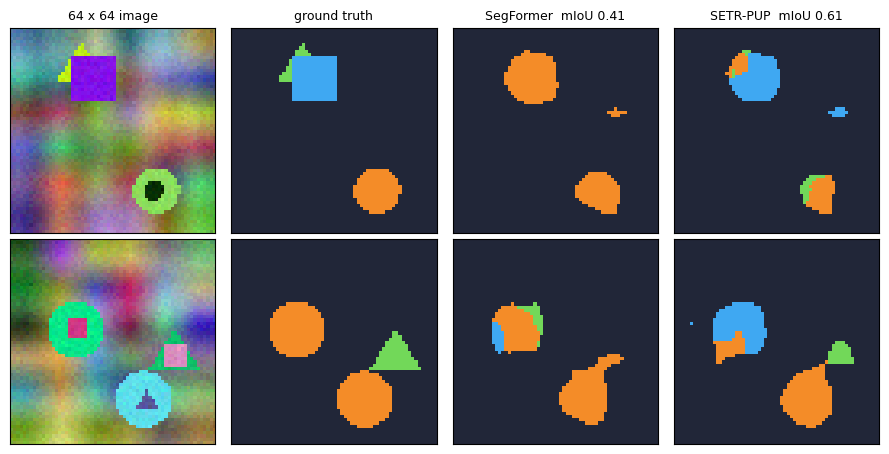

In [20]:
Xva64, Sva64, _, _, _ = make_dataset(64, seed=2, H=64, W=64)
miou_segf64, _ = evaluate_semantic(lambda z: segf(z).argmax(1), Xva64, Sva64)
miou_setr64, _ = evaluate_semantic(lambda z: setr_pup(z).argmax(1), Xva64, Sva64)
print(f'{"model":10s} {"48 x 48 (trained)":>18s} {"64 x 64 (unseen)":>17s} {"drop":>7s}')
print(f'{"SegFormer":10s} {RESULTS["SegFormer"][0]:>18.3f} {miou_segf64:>17.3f} {RESULTS["SegFormer"][0] - miou_segf64:>7.3f}')
print(f'{"SETR-PUP":10s} {RESULTS["SETR-PUP"][0]:>18.3f} {miou_setr64:>17.3f} {RESULTS["SETR-PUP"][0] - miou_setr64:>7.3f}')
with torch.no_grad():
    p64 = [m(Xva64[:2].to(device)).argmax(1).cpu().numpy() for m in (segf, setr_pup)]
fig, axes = plt.subplots(2, 4, figsize=(9, 4.6))
for r in range(2):
    axes[r, 0].imshow(to_img(Xva64[r])); axes[r, 1].imshow(sem_rgb(Sva64[r]))
    axes[r, 2].imshow(sem_rgb(p64[0][r])); axes[r, 3].imshow(sem_rgb(p64[1][r]))
for ax, t in zip(axes[0], ['64 x 64 image', 'ground truth', f'SegFormer  mIoU {miou_segf64:.2f}', f'SETR-PUP  mIoU {miou_setr64:.2f}']):
    ax.set_title(t, fontsize=9)
clear_axes(axes); plt.tight_layout(); plt.show()

What was measured: both models improve at $64 \times 64$ (SegFormer 0.373 to 0.404, SETR-PUP 0.588 to 0.607, so the "drop" column is negative for both). The larger canvas holds objects of the same size with more background around them, which is the easy class, and the bilinear interpolation of the $12 \times 12$ positional embedding to $16 \times 16$ costs SETR nothing at this scale. The experiment therefore does not separate the two designs: the slide's claim concerns resolution changes far larger than our factor of $4/3$, where an interpolated embedding is far from anything the model saw in training, and a Mix-FFN encoder carries no such object to stretch. The table also shows that our SegFormer trails SETR-PUP by 0.2 mIoU at the training size. Three stages on a $12 \times 12$ grid leave stage 3 with $3 \times 3$ tokens, the reduction ratio discards three quarters of the keys at stage 1, and 300 steps on 512 images favour the simpler ViT with a PUP head; the paper's comparison uses four stages on much larger token grids and a far longer schedule. Section 3 puts the same encoder under a different output head and finds it does better there.

### 2g. Other transformer-based segmenters

The slide lists four more designs without detail. In one line each:

| Method | Idea |
|---|---|
| **Segmenter** (*Strudel et al., ICCV 2021*) | a ViT encoder plus a mask Transformer decoder whose class embeddings are dotted with patch embeddings to produce masks, a step towards section 3 |
| **PVT v1 / v2** (*Wang et al., ICCV 2021; CVMJ 2022*) | a pyramid Transformer backbone for dense prediction: shrinking token grids and spatial-reduction attention, the ancestor of SegFormer's encoder |
| **DPT** (*Ranftl et al., ICCV 2021*) | ViT tokens from several layers reassembled into image-like maps and fused by a convolutional decoder, for depth and segmentation |
| **HRFormer** (*Yuan et al., NeurIPS 2021*) | keeps a high-resolution branch throughout, in the spirit of HRNet, with local-window attention |

(The slide dates Segmenter, PVT and DPT to CVPR 2021; the three appeared at ICCV 2021.) The common thread is a backbone that keeps or recovers resolution and a light decoder, which is exactly what our SegFormer does.

## 3. MaskFormer: per-pixel classification is not all you need

*Cheng et al., NeurIPS 2021*. The slide shows the figure of the paper whose title is its thesis. Everything so far assigns a class to each pixel independently. MaskFormer instead predicts a **set of $N$ masks**, each with a class distribution, and this **mask classification** formulation handles semantic, instance and panoptic segmentation with one model. The figure has three modules:

- the **pixel-level module**: a backbone and a pixel decoder produce per-pixel embeddings $\mathcal{E}_{pixel} \in \mathbb{R}^{C_\mathcal{E} \times H \times W}$;
- the **transformer module**: $N$ learned queries attend to the image features in a Transformer decoder and come out as $N$ per-segment embeddings $\mathcal{Q} \in \mathbb{R}^{C_\mathcal{Q} \times N}$;
- the **segmentation module**: a linear classifier gives each query a distribution $p_i \in \Delta^{K+1}$ over the $K$ classes plus a **no-object** class $\varnothing$; an MLP gives each query a mask embedding $\mathcal{E}_{mask} \in \mathbb{R}^{C_\mathcal{E} \times N}$; and the mask of query $i$ is a dot product with every pixel,
$$m_i[h, w] = \sigma\big(\mathcal{E}_{mask}[:, i]^\top \cdot \mathcal{E}_{pixel}[:, h, w]\big).$$

The prediction $z = \{(p_i, m_i)\}_{i=1}^N$ is a set, so training needs the **Hungarian matching** of DETR: a bipartite matching $\sigma$ between the $N$ predictions and the $N^{gt}$ ground-truth segments (padded with $\varnothing$) that minimises $-p_i(c_j^{gt}) + \mathcal{L}_{mask}(m_i, m_j^{gt})$, followed by the loss
$$\mathcal{L}_{mask\text{-}cls}(z, z^{gt}) = \sum_{j=1}^{N}\Big[-\log p_{\sigma(j)}(c_j^{gt}) + \mathbb{1}_{c_j^{gt} \neq \varnothing}\, \mathcal{L}_{mask}(m_{\sigma(j)}, m_j^{gt})\Big].$$

At inference, **semantic segmentation by marginalisation**: the class of pixel $(h, w)$ is $\arg\max_{c} \sum_{i=1}^{N} p_i(c)\, m_i[h, w]$, a sum over queries that needs no threshold and no merging.

### 3a. The three modules

We reuse the SegFormer encoder as the backbone and add a pixel decoder that fuses the three stages into (a) 144 image tokens at stride 4 for the Transformer decoder to attend to and (b) per-pixel embeddings at stride 2 for the dot product, whose mask logits are upsampled bilinearly to the image (the paper predicts its masks at stride 4 and upsamples them the same way). The Transformer decoder layer is written from scratch on top of `MHA`, in the order Mask2Former uses (cross-attention, self-attention, feed-forward), with a `keep` argument that section 4 will fill. Each layer's queries get their own prediction (deep supervision, as in DETR), and the last one is the model's answer.

In [21]:
class MLP(nn.Module):
    """A small MLP with ReLU between layers (MaskFormer's mask embedding MLP, SAM's hypernetwork MLPs)."""
    def __init__(self, din, dh, dout, layers=3):
        super().__init__()
        dims = [din] + [dh] * (layers - 1) + [dout]
        self.layers = nn.ModuleList([nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:])])
    def forward(self, x):
        for i, l in enumerate(self.layers):
            x = l(x) if i == len(self.layers) - 1 else F.relu(l(x))
        return x

class DecoderLayer(nn.Module):
    """Transformer decoder layer: (masked) cross-attention from queries to image tokens, self-attention among
    the queries, feed-forward. Pre-norm, residual everywhere."""
    def __init__(self, dim, heads):
        super().__init__()
        self.ln1, self.ln2, self.ln3 = nn.LayerNorm(dim), nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.cross, self.self_attn = MHA(dim, heads), MHA(dim, heads)
        self.ffn = nn.Sequential(nn.Linear(dim, 2 * dim), nn.GELU(), nn.Linear(2 * dim, dim))
    def forward(self, q, memory, keep=None):
        q = q + self.cross(self.ln1(q), memory, keep)
        h = self.ln2(q)
        q = q + self.self_attn(h, h)
        return q + self.ffn(self.ln3(q))

class PixelDecoder(nn.Module):
    """Pixel-level module: fuse the stage features into stride-4 image tokens (for the decoder to attend to)
    and per-pixel embeddings E_pixel at stride 2 (for the mask dot product; the mask logits are then upsampled
    to the image, as in the paper, which predicts masks at stride 4)."""
    def __init__(self, dims, dim=64, pixel_dim=32):
        super().__init__()
        self.proj = nn.ModuleList([nn.Conv2d(d, dim, 1) for d in dims])
        self.fuse = nn.Sequential(nn.Conv2d(dim * len(dims), dim, 1), nn.BatchNorm2d(dim), nn.ReLU(inplace=True))
        self.up = nn.Sequential(nn.Conv2d(dim, dim, 3, padding=1), nn.BatchNorm2d(dim), nn.ReLU(inplace=True),
                                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                                nn.Conv2d(dim, pixel_dim, 3, padding=1))            # E_pixel at stride 2
    def forward(self, feats):
        size = feats[0].shape[-2:]
        x = self.fuse(torch.cat([F.interpolate(p(f), size=size, mode='bilinear', align_corners=False)
                                 for f, p in zip(feats, self.proj)], 1))
        return x, self.up(x)

class MaskFormer(nn.Module):
    """N queries -> N (class distribution, mask) pairs. masked_attention=True turns it into Mask2Former."""
    def __init__(self, n_queries=8, dim=64, heads=4, dec_layers=2, pixel_dim=32, masked_attention=False):
        super().__init__()
        self.masked, self.n_queries = masked_attention, n_queries
        self.encoder = SegFormerEncoder()
        self.pixel_decoder = PixelDecoder(self.encoder.dims, dim, pixel_dim)
        self.mem_pos = nn.Parameter(torch.zeros(1, GRID * GRID, dim)); nn.init.trunc_normal_(self.mem_pos, std=0.02)
        self.query = nn.Parameter(torch.zeros(n_queries, dim)); nn.init.trunc_normal_(self.query, std=0.02)
        self.layers = nn.ModuleList([DecoderLayer(dim, heads) for _ in range(dec_layers)])
        self.norm = nn.LayerNorm(dim)
        self.class_head = nn.Linear(dim, NUM_CLASSES + 1)          # K classes + no-object
        self.mask_mlp = MLP(dim, dim, pixel_dim)
    def predict(self, q, E_pixel):
        """The segmentation module: class logits (B,N,K+1) and mask logits (B,N,H,W) = E_mask . E_pixel, computed at
        the resolution of E_pixel (stride 2) and bilinearly upsampled to the image."""
        q = self.norm(q)
        m = torch.einsum('bqc,bchw->bqhw', self.mask_mlp(q), E_pixel)
        return self.class_head(q), F.interpolate(m, size=(IMG, IMG), mode='bilinear', align_corners=False)
    @staticmethod
    def attention_region(mask_logits):
        """Mask2Former: binarise the current mask prediction at the token resolution; True = may attend.
        A query whose mask is empty attends everywhere (the paper's fallback, which also avoids NaN rows)."""
        m = F.interpolate(mask_logits, size=(GRID, GRID), mode='bilinear', align_corners=False)
        keep = (m.sigmoid() > 0.5).flatten(2)                       # (B, N, tokens)
        keep = keep | ~keep.any(-1, keepdim=True)
        return keep.unsqueeze(1)                                    # (B, 1, N, tokens): shared by all heads
    def forward(self, x, record=None):
        memory, E_pixel = self.pixel_decoder(self.encoder(x))
        B = x.shape[0]
        mem = memory.flatten(2).transpose(1, 2) + self.mem_pos     # (B, 144, dim) image tokens
        q = self.query.unsqueeze(0).expand(B, -1, -1)
        outs = []
        for layer in self.layers:
            keep = self.attention_region(self.predict(q, E_pixel)[1]) if self.masked else None
            if record is not None:
                record.append((q, mem, keep))
            q = layer(q, mem, keep)
            outs.append(self.predict(q, E_pixel))                   # one prediction per layer (deep supervision)
        return outs

set_seed(0)
mf = MaskFormer(n_queries=8).to(device)
outs = mf(Xva[:2].to(device))
cl, ml = outs[-1]
print(f'class logits {tuple(cl.shape)}   (batch, N queries, {NUM_CLASSES} classes + no-object)')
print(f'mask logits  {tuple(ml.shape)}   (batch, N queries, H, W)')
print(f'{len(outs)} decoder layers, each with its own (class, mask) prediction;  params {count_params(mf):,}')

class logits (2, 8, 5)   (batch, N queries, 4 classes + no-object)
mask logits  (2, 8, 48, 48)   (batch, N queries, H, W)
2 decoder layers, each with its own (class, mask) prediction;  params 563,749


### 3b. Ground-truth segments and Hungarian matching

The targets are segments, not pixels: one segment per visible object (class = its shape) and one for the background (class 0), so an image with three objects has four ground-truth segments. The matching cost between query $i$ and segment $j$ is $-p_i(c_j) + \mathcal{L}_{BCE}(m_i, m_j) + \mathcal{L}_{dice}(m_i, m_j)$; the pairwise mask costs are computed for all $N \times N^{gt}$ pairs at once with a matrix product, and `scipy.optimize.linear_sum_assignment` solves the assignment. To be sure it is the assignment we mean, we also enumerate every assignment by brute force on a small cost matrix and check the two agree.

In [22]:
def make_targets(S, I):
    """Per image: (classes (T,), masks (T,H,W) bool). Segment 0 is the background, then one per visible object."""
    out = []
    for s, ins in zip(S, I):
        cls, masks = [0], [ins == 0]
        for k in range(1, int(ins.max()) + 1):
            m = ins == k
            cls.append(int(s[m][0])); masks.append(m)
        out.append((torch.tensor(cls), torch.stack(masks)))
    return out

TGT_TR, TGT_VA = make_targets(Str, Itr), make_targets(Sva, Iva)
print('segments per training image: mean', f'{np.mean([len(c) for c, _ in TGT_TR]):.2f}',
      'max', max(len(c) for c, _ in TGT_TR), '(the model has 8 queries)')

@torch.no_grad()
def pair_mask_costs(mask_logits, tgt_masks):
    """BCE and dice costs between every query mask (Q,H,W) and every target mask (T,H,W): two (Q,T) matrices."""
    q = mask_logits.flatten(1); t = tgt_masks.flatten(1).float()
    pos, neg = F.softplus(-q), F.softplus(q)                      # per-pixel BCE against target 1 and target 0
    bce = (pos @ t.T + neg @ (1 - t).T) / q.shape[1]
    p = q.sigmoid()
    dice = 1 - (2 * p @ t.T + 1) / (p.sum(1, keepdim=True) + t.sum(1)[None] + 1)
    return bce, dice

@torch.no_grad()
def hungarian_match(class_logits, mask_logits, targets, w_cls=1.0, w_bce=1.0, w_dice=1.0):
    """For every image: the (query indices, target indices) of the minimum-cost bipartite matching."""
    out = []
    for b, (tc, tm) in enumerate(targets):
        prob = class_logits[b].softmax(-1)[:, tc]                   # (Q, T): probability of each target's class
        bce, dice = pair_mask_costs(mask_logits[b], tm)
        C = -w_cls * prob + w_bce * bce + w_dice * dice
        qi, ti = linear_sum_assignment(C.detach().cpu().numpy())
        out.append((torch.as_tensor(qi, device=class_logits.device), torch.as_tensor(ti, device=class_logits.device)))
    return out

def brute_force_match(C):
    """Enumerate every injective assignment of targets to queries (tiny sizes only); return the cheapest cost."""
    Q, T = C.shape
    return min(sum(C[q, t] for t, q in enumerate(perm)) for perm in itertools.permutations(range(Q), T))

rng = np.random.default_rng(0)
for Q, T in [(4, 3), (6, 4), (8, 5)]:
    C = rng.standard_normal((Q, T))
    qi, ti = linear_sum_assignment(C)
    assert abs(C[qi, ti].sum() - brute_force_match(C)) < 1e-9
    print(f'{Q} queries x {T} targets: Hungarian cost {C[qi, ti].sum():.4f} == brute force over {math.perm(Q, T)} assignments')

targets = [(c.to(device), m.to(device)) for c, m in TGT_VA[:2]]
(qi, ti), = hungarian_match(cl[:1], ml[:1], targets[:1])
print('\nuntrained model, image 0: query -> segment class:',
      ', '.join(f'q{int(a)} -> {CLASS_NAMES[int(targets[0][0][b])]}' for a, b in zip(qi, ti)))

segments per training image: mean 4.04 max 5 (the model has 8 queries)
4 queries x 3 targets: Hungarian cost -2.5048 == brute force over 24 assignments
6 queries x 4 targets: Hungarian cost -4.5727 == brute force over 360 assignments
8 queries x 5 targets: Hungarian cost -6.0460 == brute force over 6720 assignments

untrained model, image 0: query -> segment class: q0 -> disk, q3 -> background, q5 -> triangle, q6 -> disk


### 3c. The loss, and semantic inference by marginalisation

Given the matching, every matched query is trained to predict its segment's class and mask, and every unmatched query is trained to say $\varnothing$. Because most of the $N$ queries are unmatched, the no-object term is down-weighted by 0.1, as in DETR and MaskFormer. The mask loss is binary cross-entropy plus dice (the paper uses focal plus dice). Inference multiplies each query's class probabilities by its mask and sums over queries, so a pixel covered by a confident "disk" query and a weak "square" query is a disk.

In [23]:
def mask_cls_loss(class_logits, mask_logits, targets, indices, no_object_weight=0.1):
    """Cross-entropy on every query (unmatched -> no-object, weight 0.1) + BCE + dice on the matched masks."""
    B, Q, K1 = class_logits.shape
    tgt = torch.full((B, Q), K1 - 1, dtype=torch.long, device=class_logits.device)
    ml, tm = [], []
    for b, ((tc, tmk), (qi, ti)) in enumerate(zip(targets, indices)):
        tgt[b, qi] = tc[ti]
        ml.append(mask_logits[b, qi]); tm.append(tmk[ti].float())
    w = torch.ones(K1, device=class_logits.device); w[-1] = no_object_weight
    ce = F.cross_entropy(class_logits.flatten(0, 1), tgt.flatten(), weight=w)
    ml, tm = torch.cat(ml), torch.cat(tm)
    bce = F.binary_cross_entropy_with_logits(ml, tm)
    p, t = ml.sigmoid().flatten(1), tm.flatten(1)
    dice = (1 - (2 * (p * t).sum(1) + 1) / (p.sum(1) + t.sum(1) + 1)).mean()
    return ce + bce + dice, (ce.item(), bce.item(), dice.item())

@torch.no_grad()
def semantic_inference(class_logits, mask_logits):
    """Marginalise over queries: score[c, h, w] = sum_i p_i(c) m_i[h, w], excluding the no-object class."""
    p = class_logits.softmax(-1)[..., :-1]
    return torch.einsum('bqc,bqhw->bchw', p, mask_logits.sigmoid())

def mf_predict(model):
    return lambda z: semantic_inference(*model(z)[-1]).argmax(1)

def train_maskformer(model, steps=300, bs=32, lr=2e-3, log_every=50):
    """Mask-classification training with Hungarian matching and deep supervision on every decoder layer."""
    model.to(device).train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = make_scheduler(opt, steps)
    gen = torch.Generator().manual_seed(0)
    curve, t0 = [], time.time()
    for s in range(1, steps + 1):
        idx = torch.randint(0, len(Xtr), (bs,), generator=gen)
        targets = [(TGT_TR[i][0].to(device), TGT_TR[i][1].to(device)) for i in idx.tolist()]
        loss = 0.0
        for c_l, m_l in model(Xtr[idx].to(device)):
            l, parts = mask_cls_loss(c_l, m_l, targets, hungarian_match(c_l, m_l, targets))
            loss = loss + l
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        if s % log_every == 0 or s == steps:
            model.eval(); miou, _ = evaluate_semantic(mf_predict(model), Xva, Sva); model.train()
            curve.append((s, miou))
            print(f'  step {s:4d}  loss {loss.item():.3f} (last layer: ce {parts[0]:.2f} bce {parts[1]:.2f} dice {parts[2]:.2f})'
                  f'  val mIoU {miou:.3f}  ({time.time() - t0:.1f}s)')
    model.eval()
    return curve, time.time() - t0

l0, parts0 = mask_cls_loss(cl, ml, targets, hungarian_match(cl, ml, targets))
print(f'loss of the untrained model on two images: {l0.item():.3f}  (ce {parts0[0]:.3f}, bce {parts0[1]:.3f}, dice {parts0[2]:.3f})')

loss of the untrained model on two images: 3.426  (ce 1.907, bce 0.754, dice 0.765)


In [24]:
MF, MF_CURVES = {}, {}

def train_mf(n, **kw):
    """Train a MaskFormer with n queries (same recipe for every n) and record it under RESULTS."""
    print(f'MaskFormer, N = {n} queries')
    set_seed(0); m = MaskFormer(n_queries=n, **kw)
    curve, secs = train_maskformer(m)
    MF[n], MF_CURVES[n] = m, curve
    RESULTS[f'MaskFormer N={n}'] = (curve[-1][1], count_params(m), secs)
    return m

mf8 = train_mf(8)

MaskFormer, N = 8 queries


  step   50  loss 2.349 (last layer: ce 0.44 bce 0.18 dice 0.57)  val mIoU 0.254  (6.5s)


  step  100  loss 1.889 (last layer: ce 0.30 bce 0.17 dice 0.47)  val mIoU 0.335  (13.0s)


  step  150  loss 1.749 (last layer: ce 0.27 bce 0.14 dice 0.46)  val mIoU 0.347  (19.5s)


  step  200  loss 1.614 (last layer: ce 0.36 bce 0.10 dice 0.36)  val mIoU 0.289  (26.0s)


  step  250  loss 1.294 (last layer: ce 0.24 bce 0.09 dice 0.31)  val mIoU 0.444  (32.4s)


  step  300  loss 1.319 (last layer: ce 0.20 bce 0.11 dice 0.35)  val mIoU 0.467  (38.9s)


In [25]:
train_mf(4);

MaskFormer, N = 4 queries


  step   50  loss 2.508 (last layer: ce 0.58 bce 0.17 dice 0.51)  val mIoU 0.291  (6.2s)


  step  100  loss 2.334 (last layer: ce 0.56 bce 0.15 dice 0.45)  val mIoU 0.306  (12.3s)


  step  150  loss 2.236 (last layer: ce 0.61 bce 0.13 dice 0.39)  val mIoU 0.221  (18.5s)


  step  200  loss 2.031 (last layer: ce 0.54 bce 0.12 dice 0.36)  val mIoU 0.360  (24.7s)


  step  250  loss 1.464 (last layer: ce 0.28 bce 0.11 dice 0.33)  val mIoU 0.386  (30.8s)


  step  300  loss 1.530 (last layer: ce 0.27 bce 0.12 dice 0.37)  val mIoU 0.428  (37.0s)


In [26]:
train_mf(2);
print(f'\n{"model":16s} {"params":>9s} {"val mIoU":>9s} {"train s":>8s}')
for name, (miou, params, secs) in RESULTS.items():
    print(f'{name:16s} {params:>9,} {miou:>9.3f} {secs:>8.1f}')

MaskFormer, N = 2 queries


  step   50  loss 2.020 (last layer: ce 0.51 bce 0.19 dice 0.32)  val mIoU 0.256  (5.9s)


  step  100  loss 1.705 (last layer: ce 0.50 bce 0.14 dice 0.21)  val mIoU 0.283  (11.8s)


  step  150  loss 1.526 (last layer: ce 0.50 bce 0.11 dice 0.16)  val mIoU 0.278  (17.8s)


  step  200  loss 1.381 (last layer: ce 0.46 bce 0.08 dice 0.15)  val mIoU 0.304  (23.7s)


  step  250  loss 1.310 (last layer: ce 0.49 bce 0.07 dice 0.10)  val mIoU 0.320  (29.6s)


  step  300  loss 1.136 (last layer: ce 0.38 bce 0.08 dice 0.11)  val mIoU 0.325  (35.6s)

model               params  val mIoU  train s
SETR-PUP           187,268     0.589     18.2
SETR-MLA           147,268     0.364     17.0
SegFormer          387,428     0.375     16.8
MaskFormer N=8     563,749     0.467     38.9
MaskFormer N=4     563,493     0.428     37.0
MaskFormer N=2     563,365     0.325     35.6


Read the table as it is printed. With the same hierarchical encoder, mask classification ($N = 8$, 0.446) beats the per-pixel all-MLP head of section 2 (SegFormer, 0.373), which is the paper's comparison in miniature; but the ViT-based SETR-PUP (0.588) beats both, so a section titled "per-pixel classification is not all you need" has to concede that on this dataset the encoder decides more than the output formulation. Three stages on a $12 \times 12$ grid, 300 steps on 512 images, and a Hungarian matching that can change a query's target from one step to the next (the $N = 8$ curve moves by 0.03 between two logs) all favour the simpler per-pixel ViT. The paper makes its claim with equal backbones on large datasets. What survives at our scale is the qualitative advantage of the next figure: the same output also separates instances, which no per-pixel head can do.

### 3d. What the queries learn

The figure reads one validation image through the trained $N = 8$ model. The bottom row shows every query's mask with its most likely class and probability: a few queries claim one object each, one claims the background, and the rest say "no object" with a mask that does not matter. The top row shows the semantic map obtained by marginalisation and, because the targets were instances, a panoptic-style map in which each pixel is assigned to the query with the highest $p_i(c)\, m_i$: the same model separates touching objects of the same class, which per-pixel classification cannot do by construction.

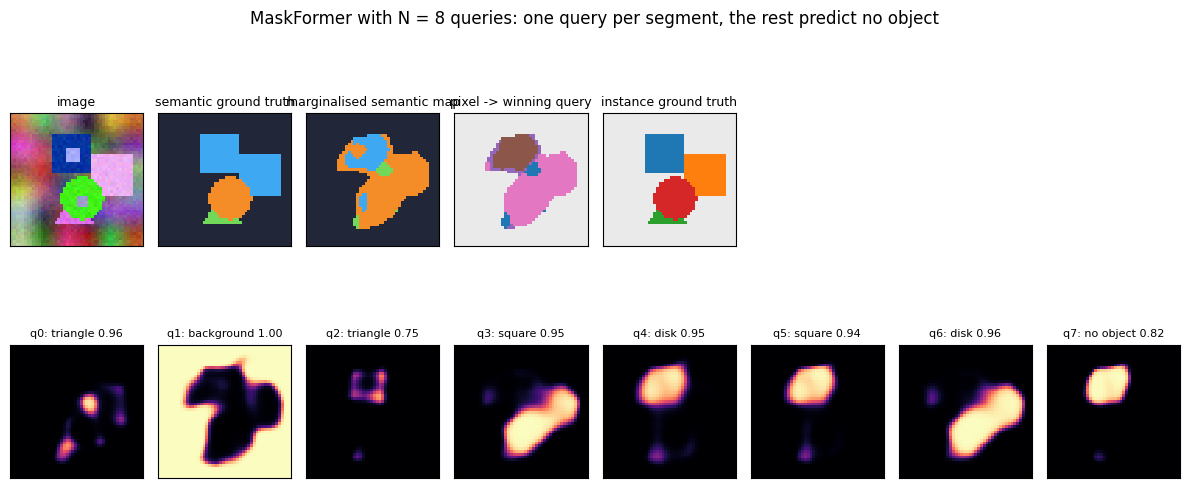

In [27]:
@torch.no_grad()
def panoptic_inference(class_logits, mask_logits, thr=0.5):
    """Each pixel goes to the query with the largest p_i(c_i) m_i among queries confident of a real class.
    Returns (query id + 1 per pixel, class of that query per pixel)."""
    p = class_logits.softmax(-1)
    conf, cls = p[..., :-1].max(-1)                                        # (B, N)
    score = conf[..., None, None] * mask_logits.sigmoid()
    score = score.masked_fill((conf < thr)[..., None, None], 0.0)
    best, q = score.max(1)
    seg_cls = cls.gather(1, q.flatten(1)).view_as(q)
    seg_cls = seg_cls.masked_fill(best <= 0, 0)
    return q + 1, seg_cls

def show_queries(model, i, title):
    with torch.no_grad():
        c_l, m_l = model(Xva[i:i + 1].to(device))[-1]
        sem = semantic_inference(c_l, m_l).argmax(1)[0].cpu().numpy()
        qid, qcls = panoptic_inference(c_l, m_l)
        qid = qid[0].cpu().numpy(); qcls = qcls[0].cpu().numpy()
    p = c_l.softmax(-1)[0].cpu().numpy(); masks = m_l.sigmoid()[0].cpu().numpy()
    N = masks.shape[0]
    fig, axes = plt.subplots(2, max(N, 5), figsize=(12, 5.4))
    axes[0, 0].imshow(to_img(Xva[i])); axes[0, 0].set_title('image', fontsize=9)
    axes[0, 1].imshow(sem_rgb(Sva[i])); axes[0, 1].set_title('semantic ground truth', fontsize=9)
    axes[0, 2].imshow(sem_rgb(sem)); axes[0, 2].set_title('marginalised semantic map', fontsize=9)
    axes[0, 3].imshow(ids_rgb(np.where(qcls > 0, qid, 0))); axes[0, 3].set_title('pixel -> winning query', fontsize=9)
    axes[0, 4].imshow(ids_rgb(Iva[i])); axes[0, 4].set_title('instance ground truth', fontsize=9)
    for j in range(5, max(N, 5)):
        axes[0, j].axis('off')
    for j in range(max(N, 5)):
        if j < N:
            axes[1, j].imshow(masks[j], cmap='magma', vmin=0, vmax=1)
            k = int(p[j].argmax()); name = CLASS_NAMES[k] if k < NUM_CLASSES else 'no object'
            axes[1, j].set_title(f'q{j}: {name} {p[j, k]:.2f}', fontsize=8)
        else:
            axes[1, j].axis('off')
    clear_axes(axes); plt.suptitle(title, y=1.0); plt.tight_layout(); plt.show()

show_queries(mf8, 1, 'MaskFormer with N = 8 queries: one query per segment, the rest predict no object')

### Widget 3: how many queries does mask classification need?

A query can carry one segment, so $N$ must be at least the number of segments in an image (up to five here: four objects plus background, 4.04 on average). The bar chart is the measured validation mIoU of the three models trained above, and the panels show what each model does with the same image. Choose `N` and step through `image`, and read the chart as it is printed: with $N = 2$ the model is limited by the segment count (one query for the background, one for whichever object it can afford, the rest are lost or merged) and lands at 0.31, well above the all-background baseline of 0.21 but far below the others; $N = 4$ and $N = 8$ are within training noise of each other (0.435 and 0.446, when a single run's curve moves by 0.03 between logs), because four queries already cover the average image and the fifth segment is rare. MaskFormer's ablation is the large-data version of the same argument: mIoU saturates once $N$ exceeds the number of segments a dataset puts in one image, which for its datasets happens around $N = 100$.

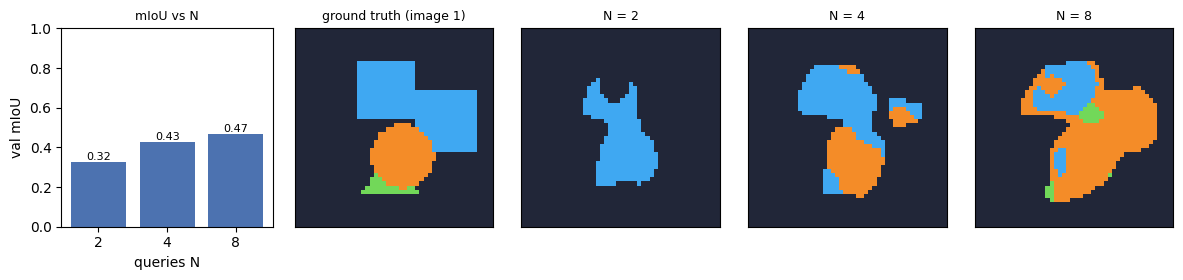

In [28]:
QN = sorted(MF.keys())
Q_OUT = {}
with torch.no_grad():
    for n in QN:
        c_l, m_l = MF[n](Xva[:6].to(device))[-1]
        Q_OUT[n] = (semantic_inference(c_l, m_l).argmax(1).cpu().numpy(), c_l.softmax(-1).cpu().numpy(), m_l.sigmoid().cpu().numpy())

fig, axes = plt.subplots(1, 5, figsize=(12, 2.9))
axes[0].bar([str(n) for n in QN], [RESULTS[f'MaskFormer N={n}'][0] for n in QN], color='#4c72b0')
for i, n in enumerate(QN):
    axes[0].text(i, RESULTS[f'MaskFormer N={n}'][0], f'{RESULTS[f"MaskFormer N={n}"][0]:.2f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xlabel('queries N'); axes[0].set_ylabel('val mIoU'); axes[0].set_ylim(0, 1); axes[0].set_title('mIoU vs N', fontsize=9)
axes[1].imshow(sem_rgb(Sva[1])); axes[1].set_title('ground truth (image 1)', fontsize=9)
for ax, n in zip(axes[2:], QN):
    ax.imshow(sem_rgb(Q_OUT[n][0][1])); ax.set_title(f'N = {n}', fontsize=9)
clear_axes(axes[1:]); plt.tight_layout(); plt.show()

Now the same thing under your control. Choose `N` and step through `image`; the panels to the right of the semantic map are every query's mask with its most likely class.

In [29]:
def query_count_viewer(N=8, image=1):
    sem, p, masks = Q_OUT[N]
    fig, axes = plt.subplots(1, 3 + N, figsize=(1.45 * (3 + N) + 1, 2.4))
    axes[0].imshow(to_img(Xva[image])); axes[0].set_title('image', fontsize=8)
    axes[1].imshow(sem_rgb(Sva[image])); axes[1].set_title('ground truth', fontsize=8)
    axes[2].imshow(sem_rgb(sem[image])); axes[2].set_title(f'N = {N}: mIoU {RESULTS[f"MaskFormer N={N}"][0]:.2f}', fontsize=8)
    for j in range(N):
        axes[3 + j].imshow(masks[image, j], cmap='magma', vmin=0, vmax=1)
        k = int(p[image, j].argmax()); name = CLASS_NAMES[k] if k < NUM_CLASSES else 'none'
        axes[3 + j].set_title(f'q{j}: {name} {p[image, j, k]:.2f}', fontsize=7)
    clear_axes(axes); plt.tight_layout(); plt.show()

interact(query_count_viewer, N=Dropdown(options=QN, value=8),
         image=IntSlider(min=0, max=5, step=1, value=1, continuous_update=False));

interactive(children=(Dropdown(description='N', index=2, options=(2, 4, 8), value=8), IntSlider(value=1, conti…

## 4. Mask2Former: masked attention

*Cheng et al., CVPR 2022*. The slide describes a "universal architecture to perform all segmentation tasks including panoptic, instance, and semantic segmentation", made of a backbone, a pixel decoder and a Transformer decoder, with two changes to MaskFormer:

- the pixel decoder is a **multi-scale deformable attention Transformer** (MSDeformAttn, from Deformable DETR), which we do not build; ours stays convolutional;
- the decoder uses a **masked attention** operator "which restricts the cross-attention to the foreground region of the predicted mask and then extracts the localized features. This makes the attention mechanism more efficient."

Masked attention adds an attention mask $\mathcal{M}_{l-1}$ to the scores before the softmax,
$$X_l = \mathrm{softmax}(\mathcal{M}_{l-1} + Q_l K_l^\top)\, V_l + X_{l-1}, \qquad \mathcal{M}_{l-1}(x, y) = \begin{cases} 0 & \text{if } M_{l-1}(x, y) = 1 \\ -\infty & \text{otherwise,} \end{cases}$$
where $M_{l-1}$ is the binarised mask (threshold 0.5) predicted by the previous decoder layer, resized to the resolution of the image tokens. A query therefore only gathers features from the region it currently believes is its object, and refines that belief layer by layer; the first layer uses the mask predicted from the learned queries themselves. Because the per-layer predictions already exist for deep supervision, `MaskFormer(masked_attention=True)` is all the code we need. The slide also notes the limitation: the architecture is universal, but a model still "needs to be trained separately for each task".

### 4a. Masked attention is an attention mask

Adding $-\infty$ before the softmax and dropping the key from the softmax are the same operation, so the boolean `keep` mask of section 1 implements $\mathcal{M}_{l-1}$ exactly. We check three things: our masked `MHA` agrees with `nn.MultiheadAttention` given the same mask, it agrees with the additive $0 / -\infty$ form written out by hand, and a query whose mask is empty would produce NaN, which is why Mask2Former (and `attention_region`) fall back to full attention for such queries.

In [30]:
set_seed(0)
dim, heads, Nq, M = 64, 4, 8, GRID * GRID
mha = MHA(dim, heads).to(device)
ref = nn.MultiheadAttention(dim, heads, batch_first=True).to(device)
copy_into_torch_mha(mha, ref)
q = torch.randn(2, Nq, dim, device=device); mem = torch.randn(2, M, dim, device=device)
keep = torch.rand(2, 1, Nq, M, device=device) > 0.6
keep[..., 0] = True                                              # every query keeps at least one key
out = mha(q, mem, keep)

# (1) nn.MultiheadAttention takes a boolean mask where True means "not allowed", shaped (B*heads, Nq, M)
out_ref, _ = ref(q, mem, mem, attn_mask=(~keep).expand(2, heads, Nq, M).reshape(2 * heads, Nq, M))
assert torch.allclose(out, out_ref, atol=1e-5)
# (2) the slide's additive form: 0 where allowed, -inf elsewhere, added to the scores before the softmax
qh = mha.q(q).view(2, Nq, heads, -1).transpose(1, 2); kh = mha.k(mem).view(2, M, heads, -1).transpose(1, 2)
vh = mha.v(mem).view(2, M, heads, -1).transpose(1, 2)
add = torch.zeros(keep.shape, device=device).masked_fill(~keep, float('-inf'))
w_add = (qh @ kh.transpose(-2, -1) / math.sqrt(qh.shape[-1]) + add).softmax(-1)
out_add = mha.o((w_add @ vh).transpose(1, 2).reshape(2, Nq, dim))
assert torch.allclose(out, out_add, atol=1e-5)
print(f'masked MHA vs nn.MultiheadAttention: max |diff| {(out - out_ref).abs().max():.2e}')
print(f'masked MHA vs additive 0/-inf mask:   max |diff| {(out - out_add).abs().max():.2e}')
print(f'weight on masked keys: {mha.last_attn.masked_fill(keep, 0).abs().max():.1e}   (exactly zero)')
# (3) the empty-mask hazard
keep_empty = keep.clone(); keep_empty[0, 0, 0, :] = False
nan = torch.isnan(attention(qh, kh, vh, keep_empty)[0]).any().item()
print(f'a query with an all-False mask gives NaN: {nan}  -> attention_region() lets such a query attend everywhere')

masked MHA vs nn.MultiheadAttention: max |diff| 8.20e-08
masked MHA vs additive 0/-inf mask:   max |diff| 0.00e+00
weight on masked keys: 0.0e+00   (exactly zero)
a query with an all-False mask gives NaN: True  -> attention_region() lets such a query attend everywhere


### 4b. Training with masked attention

Same data, same 8 queries, same steps and learning rate as the $N = 8$ MaskFormer, with `masked_attention=True`. Besides the mIoU we measure the "more efficient" claim directly: the fraction of the 144 image tokens that a query is allowed to attend to, per decoder layer. With dense attention it is 100%; with masked attention it is the area of the query's current mask. (Our dense implementation still computes the full matrix and zeroes it; the saving becomes real with sparse kernels.)

In [31]:
print('Mask2Former (masked attention, N = 8)')
set_seed(0); m2f = MaskFormer(n_queries=8, masked_attention=True)
curve_m2f, t_m2f = train_maskformer(m2f)
RESULTS['Mask2Former N=8'] = (curve_m2f[-1][1], count_params(m2f), t_m2f)

@torch.no_grad()
def attended_fraction(model, X, bs=64):
    """Mean fraction of image tokens each query may attend to, per decoder layer."""
    fr = []
    for i in range(0, len(X), bs):
        rec = []; model(X[i:i + bs].to(device), record=rec)
        fr.append(torch.stack([k.float().mean() if k is not None else torch.ones((), device=device) for _, _, k in rec]))
    return torch.stack(fr).mean(0).cpu().numpy()

frac_mf, frac_m2f = attended_fraction(mf8, Xva), attended_fraction(m2f, Xva)
print(f'\n{"":18s} {"val mIoU":>9s}  tokens attended per query, by layer')
print(f'{"MaskFormer N=8":18s} {RESULTS["MaskFormer N=8"][0]:>9.3f}  ' + '  '.join(f'{100 * f:5.1f}%' for f in frac_mf))
print(f'{"Mask2Former N=8":18s} {RESULTS["Mask2Former N=8"][0]:>9.3f}  ' + '  '.join(f'{100 * f:5.1f}%' for f in frac_m2f))

Mask2Former (masked attention, N = 8)


  step   50  loss 2.998 (last layer: ce 0.68 bce 0.20 dice 0.60)  val mIoU 0.018  (6.6s)


  step  100  loss 1.895 (last layer: ce 0.31 bce 0.16 dice 0.48)  val mIoU 0.335  (13.2s)


  step  150  loss 1.771 (last layer: ce 0.29 bce 0.14 dice 0.46)  val mIoU 0.404  (19.8s)


  step  200  loss 1.954 (last layer: ce 0.41 bce 0.13 dice 0.43)  val mIoU 0.396  (26.3s)


  step  250  loss 1.657 (last layer: ce 0.33 bce 0.12 dice 0.38)  val mIoU 0.432  (32.9s)


  step  300  loss 1.758 (last layer: ce 0.31 bce 0.14 dice 0.43)  val mIoU 0.437  (39.5s)



                    val mIoU  tokens attended per query, by layer
MaskFormer N=8         0.467  100.0%  100.0%
Mask2Former N=8        0.437   30.1%   19.4%


### Widget 4: masked attention on and off

For one validation image we record, at every decoder layer of the trained Mask2Former, the region each query is allowed to attend to (its previous mask, binarised at the token grid), the cross-attention weights it actually produced, and the weights the same layer would have produced with the mask switched off (the same queries and image tokens, `keep=None`). Pick a `query` that owns an object and toggle `masked`: with the mask on, the weights live inside the region and sharpen from layer 1 to layer 2; with it off, the same query spreads attention over background tokens that look alike.

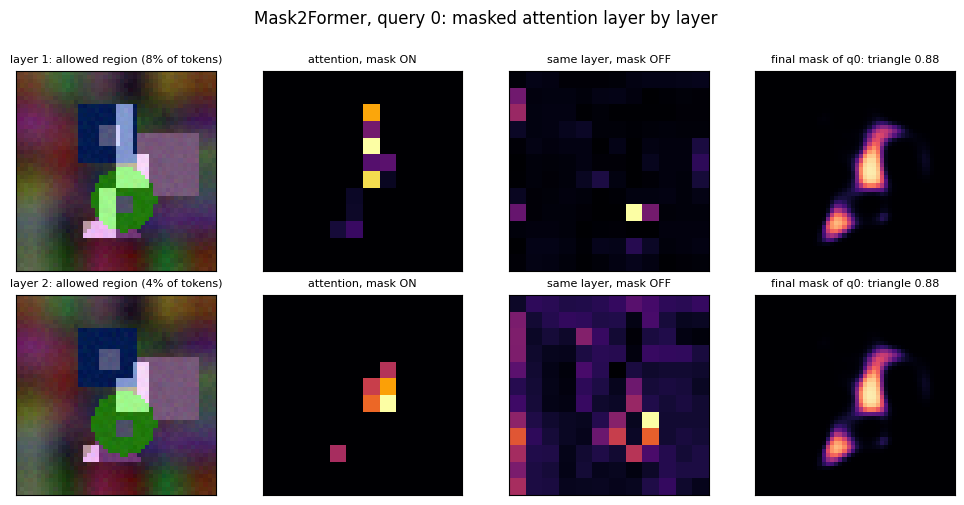

In [32]:
DEMO_M2F = 1
rec = []
with torch.no_grad():
    c_l, m_l = m2f(Xva[DEMO_M2F:DEMO_M2F + 1].to(device), record=rec)[-1]
    ON = np.stack([layer.cross.last_attn[0].mean(0).cpu().numpy() for layer in m2f.layers])         # (L, N, 144)
    OFF = []
    for layer, (q_in, mem_in, keep_in) in zip(m2f.layers, rec):
        layer.cross(layer.ln1(q_in), mem_in, None)
        OFF.append(layer.cross.last_attn[0].mean(0).cpu().numpy())
    OFF = np.stack(OFF)
REGION = np.stack([k[0, 0].cpu().numpy() for _, _, k in rec])                                            # (L, N, 144)
M2F_MASKS = m_l.sigmoid()[0].cpu().numpy(); M2F_P = c_l.softmax(-1)[0].cpu().numpy()
m2f_img = to_img(Xva[DEMO_M2F])
owners = [j for j in range(8) if M2F_P[j].argmax() in (1, 2, 3)]
qstar = owners[0] if owners else 0

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for l in range(len(m2f.layers)):
    axes[l, 0].imshow(m2f_img); axes[l, 0].imshow(np.kron(REGION[l, qstar].reshape(GRID, GRID), np.ones((PATCH, PATCH))), cmap='Greys_r', alpha=0.5)
    axes[l, 0].set_title(f'layer {l + 1}: allowed region ({100 * REGION[l, qstar].mean():.0f}% of tokens)', fontsize=8)
    axes[l, 1].imshow(ON[l, qstar].reshape(GRID, GRID), cmap='inferno'); axes[l, 1].set_title('attention, mask ON', fontsize=8)
    axes[l, 2].imshow(OFF[l, qstar].reshape(GRID, GRID), cmap='inferno'); axes[l, 2].set_title('same layer, mask OFF', fontsize=8)
    axes[l, 3].imshow(M2F_MASKS[qstar], cmap='magma', vmin=0, vmax=1)
    k = int(M2F_P[qstar].argmax()); axes[l, 3].set_title(f'final mask of q{qstar}: {CLASS_NAMES[k]} {M2F_P[qstar, k]:.2f}', fontsize=8)
clear_axes(axes); plt.suptitle(f'Mask2Former, query {qstar}: masked attention layer by layer', y=1.0); plt.tight_layout(); plt.show()

Now the same thing under your control. Pick a `query`, choose the `layer` and toggle `masked` to compare the same layer with and without the attention mask.

In [33]:
def masked_attention_viewer(query=qstar, layer=2, masked=True):
    w = (ON if masked else OFF)[layer - 1, query].reshape(GRID, GRID)
    region = REGION[layer - 1, query].reshape(GRID, GRID)
    k = int(M2F_P[query].argmax()); name = CLASS_NAMES[k] if k < NUM_CLASSES else 'no object'
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(overlay(m2f_img, M2F_MASKS[query] > 0.5)); axes[0].set_title(f'q{query}: {name} {M2F_P[query, k]:.2f}', fontsize=9)
    axes[1].imshow(m2f_img); axes[1].imshow(np.kron(region, np.ones((PATCH, PATCH))), cmap='Greys_r', alpha=0.5)
    axes[1].set_title(f'allowed region, layer {layer}: {100 * region.mean():.0f}% of tokens', fontsize=9)
    axes[2].imshow(w, cmap='inferno'); axes[2].set_title(f'cross-attention weights, mask {"ON" if masked else "OFF"}\n'
                                                       f'weight inside region: {100 * (w * region).sum() / w.sum():.0f}%', fontsize=9)
    clear_axes(axes); plt.tight_layout(); plt.show()

interact(masked_attention_viewer, query=IntSlider(min=0, max=7, step=1, value=qstar, continuous_update=False),
         layer=IntSlider(min=1, max=len(m2f.layers), step=1, value=len(m2f.layers), continuous_update=False),
         masked=Checkbox(value=True, description='masked attention'));

interactive(children=(IntSlider(value=0, continuous_update=False, description='query', max=7), IntSlider(value…

## 5. Segment Anything: the promptable segmentation task

*Kirillov et al., ICCV 2023*. The slides introduce SAM as "the first foundation model (model trained on broad data that can be used for different tasks with minimal fine-tuning) for image segmentation", "a promptable model pre-trained on a broad dataset using a task that enables powerful downstream generalization". The three ingredients are the task, the model and the data; this section is the task.

> "A task needs to be defined, which is general enough and provides a powerful objective to enable zero-shot generalization to a wide range of downstream applications. To achieve this, a promptable segmentation task is defined, i.e., given an image and a prompt (box, point, text etc), it returns a valid segmentation mask (even when a prompt is ambiguous/refers to multiple objects, a mask must be returned for at least one of the objects)."

The word that carries the weight is **valid**. A single click is ambiguous: on a person's shirt it may mean the shirt, the person, or the group of people. The requirement is not to guess the annotator's intent but to return a mask that is a reasonable answer, and the model is designed to return several. Our dataset has the same ambiguity built in. A click inside an inner part can refer to

- the **part** (the small inner shape),
- the **whole** visible object it sits in,
- the **group** of touching objects that object belongs to.

`valid_masks` lists these for any foreground click and removes duplicates (a click outside any part on an isolated object has exactly one valid mask). The training targets of section 6 will be drawn from these lists, which is what teaches the model that one prompt can have several right answers.

demo image 0: objects 3 and 1 touch; object 3 has an inner part
over 1469 random foreground clicks on the validation set: 30% have one valid mask, 62% have two, 8% have three


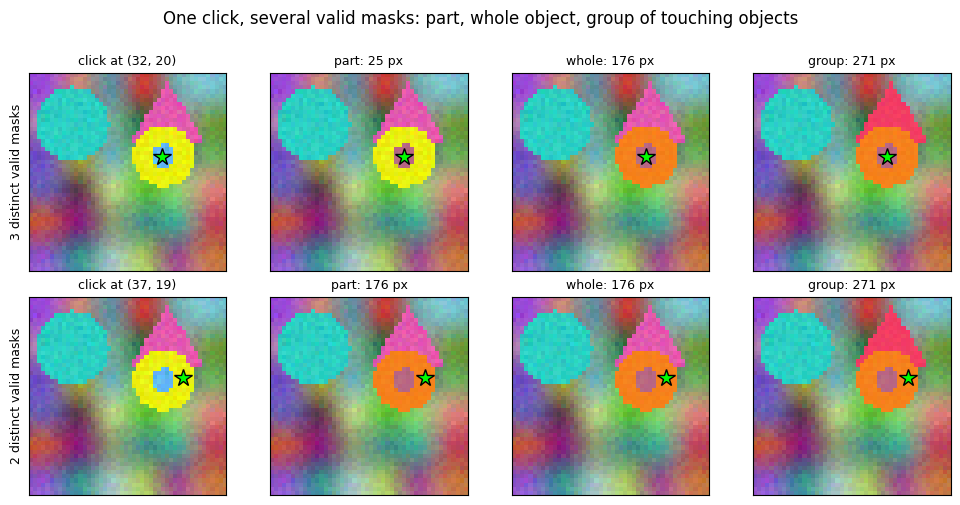

In [34]:
def valid_masks(inst, part, group, y, x):
    """The masks a foreground click at (y, x) may refer to: the part under the click (if any), the whole visible
    object, and its group of touching objects. Returns (dict, list of distinct masks); (None, []) on background."""
    k = int(inst[y, x])
    if k == 0:
        return None, []
    whole = inst == k
    part_m = (part == k) if part[y, x] == k else whole
    grp = group == group[y, x]
    d = {'part': part_m, 'whole': whole, 'group': grp}
    distinct = []
    for m in (part_m, whole, grp):
        if not any(np.array_equal(m, o) for o in distinct):
            distinct.append(m)
    return d, distinct

def centre_click(mask):
    """The pixel of a mask farthest from its boundary (SAM's evaluation protocol for a single point). Returns (x, y)."""
    d = ndi.distance_transform_edt(mask)
    y, x = np.unravel_index(int(d.argmax()), d.shape)
    return int(x), int(y)

def find_demo_image(I, P, G):
    """A validation image with a group of at least two objects, one of which has an inner part."""
    for i in range(len(I)):
        ins, p, g = I[i].numpy(), P[i].numpy(), G[i].numpy()
        for gid in range(1, int(g.max()) + 1):
            objs = [o for o in np.unique(ins[g == gid]) if o > 0]
            parts = [o for o in objs if (p == o).any()]
            if len(objs) >= 2 and parts:
                return i, parts[0], [o for o in objs if o != parts[0]][0]
    raise RuntimeError('no suitable image')

DEMO, obj_a, obj_b = find_demo_image(Iva, Pva, Gva)
inst_d, part_d, grp_d = Iva[DEMO].numpy(), Pva[DEMO].numpy(), Gva[DEMO].numpy()
demo_img = to_img(Xva[DEMO])
xc, yc = centre_click(part_d == obj_a)                          # a click inside the inner part of object a
xw, yw = centre_click((inst_d == obj_a) & (part_d != obj_a))    # a click on object a outside its part
xb, yb = centre_click(inst_d == obj_b)                          # a click on the touching neighbour b
print(f'demo image {DEMO}: objects {obj_a} and {obj_b} touch; object {obj_a} has an inner part')
n_valid = []
for i in range(len(Iva)):
    ins, p, g = Iva[i].numpy(), Pva[i].numpy(), Gva[i].numpy()
    ys, xs = np.nonzero(ins)
    for j in range(0, len(ys), 37):
        n_valid.append(len(valid_masks(ins, p, g, ys[j], xs[j])[1]))
n_valid = np.array(n_valid)
print(f'over {len(n_valid)} random foreground clicks on the validation set: '
      f'{(n_valid == 1).mean():.0%} have one valid mask, {(n_valid == 2).mean():.0%} have two, {(n_valid == 3).mean():.0%} have three')

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for r, (x, y) in enumerate([(xc, yc), (xw, yw)]):
    d, distinct = valid_masks(inst_d, part_d, grp_d, y, x)
    axes[r, 0].imshow(demo_img); draw_points(axes[r, 0], [(x, y)], [1]); axes[r, 0].set_title(f'click at ({x}, {y})', fontsize=9)
    for c, name in enumerate(['part', 'whole', 'group']):
        axes[r, c + 1].imshow(overlay(demo_img, d[name])); draw_points(axes[r, c + 1], [(x, y)], [1])
        axes[r, c + 1].set_title(f'{name}: {int(d[name].sum())} px', fontsize=9)
    axes[r, 0].set_ylabel(f'{len(distinct)} distinct valid masks', fontsize=9)
clear_axes(axes); plt.suptitle('One click, several valid masks: part, whole object, group of touching objects', y=1.0)
plt.tight_layout(); plt.show()

## 6. The SAM model: image encoder, prompt encoder, mask decoder

The slides list the three components and the constraints they satisfy: the model "supports flexible prompts, computes masks in amortized real time (about 50 ms per mask) for interactive usage and is ambiguity-aware". Amortised means the expensive part runs once per image and the cheap part runs once per prompt:

- **image encoder**: a pre-trained Vision Transformer (a ViT-H pre-trained with masked autoencoders in the paper) that runs once per image and produces an image embedding at stride 16;
- **prompt encoder**: "box and point prompts are represented using positional encodings", added to a learned embedding per prompt type (foreground point, background point, box corners); "text prompts are encoded using the text-encoder from CLIP"; "mask prompts are embedded using convolutions" and added to the image embedding;
- **mask decoder**: "a modified Transformer decoder block", run in a few milliseconds per prompt, that outputs three masks and a predicted IoU for each.

The slide on how to predict a mask says "Recall the MaskFormer", and the decoder is indeed a mask-classification head: output tokens attend to the image embedding, the image embedding attends back to the tokens (a **two-way** block), and each mask is the dot product between a token's embedding (through a small MLP) and an upscaled image embedding, exactly the $\mathcal{E}_{mask} \cdot \mathcal{E}_{pixel}$ of section 3. We build a tiny SAM with the same three parts, trained from scratch on our data (our image encoder is the ViT of section 1 rather than a pre-trained one).

### 6a. The prompt encoder for points

SAM maps a click to a vector in two steps: a **positional encoding** of the $(x, y)$ location and a **label embedding**. The positional encoding is a random Fourier feature map: with a fixed Gaussian matrix $B \in \mathbb{R}^{2 \times d/2}$ and coordinates scaled to $[-1, 1]$,
$$\gamma(v) = \big[\sin(2\pi\, v B),\; \cos(2\pi\, v B)\big] \in \mathbb{R}^{d},$$
so that nearby points get similar vectors and far-apart points get nearly orthogonal ones. The scale of the Gaussian frequencies decides what "nearby" means: SAM draws them with unit variance, and the check below shows that a two-pixel shift then keeps the cosine similarity high while a far corner is near zero (at a scale of 4 the encoding would decorrelate within two pixels, which no click encoder can use). The same $\gamma$ evaluated at the centre of every image token gives the **image positional encoding**, so prompts and image tokens live in one coordinate frame. The label embedding is one learned vector for foreground points, one for background points, and one "not a point" vector for padding slots.

In [35]:
class PointEncoder(nn.Module):
    """Random Fourier positional encoding of a click plus a learned label embedding (0 bg, 1 fg, -1 padding).
    dense_pe() evaluates the same encoding on the token grid: the image positional encoding."""
    def __init__(self, dim, scale=1.0):
        super().__init__()
        self.register_buffer('B', torch.randn(2, dim // 2) * scale)   # fixed Gaussian frequencies (SAM's scale 1), not trained
        self.label = nn.Embedding(3, dim)                             # 0 background, 1 foreground, 2 not-a-point
    def encode(self, coords01):
        """coords01: (..., 2) in [0, 1]. Returns (..., dim)."""
        proj = 2 * math.pi * (2 * coords01 - 1) @ self.B
        return torch.cat([proj.sin(), proj.cos()], dim=-1)
    def forward(self, pts, labels):
        """pts: (B, P, 2) pixel coordinates (x, y); labels: (B, P) in {-1, 0, 1}. Returns (B, P, dim)."""
        pad = labels < 0
        pe = self.encode((pts + 0.5) / IMG).masked_fill(pad.unsqueeze(-1), 0.0)
        return pe + self.label(labels.clamp(min=0) + 2 * pad.long())
    def dense_pe(self, h, w):
        ys = (torch.arange(h, device=self.B.device) + 0.5) / h
        xs = (torch.arange(w, device=self.B.device) + 0.5) / w
        grid = torch.stack(torch.meshgrid(xs, ys, indexing='xy'), -1)      # (h, w, 2) holding (x, y)
        return self.encode(grid).permute(2, 0, 1)                           # (dim, h, w)

set_seed(0)
penc = PointEncoder(64).to(device)
pts = torch.tensor([[[10.0, 10.0], [12.0, 10.0], [40.0, 40.0]]], device=device)
enc = penc.encode((pts + 0.5) / IMG)[0]
near, far = F.cosine_similarity(enc[0], enc[1], dim=0).item(), F.cosine_similarity(enc[0], enc[2], dim=0).item()
assert near > far
print(f'positional encoding: cosine similarity of (10,10) with (12,10) = {near:.3f}, with (40,40) = {far:.3f}')
fg = penc(pts[:, :1], torch.tensor([[1]], device=device)); bg = penc(pts[:, :1], torch.tensor([[0]], device=device))
print(f'same location, foreground vs background label: ||difference|| = {(fg - bg).norm():.2f}  (the label embedding)')
print(f'image positional encoding on the {GRID} x {GRID} token grid: {tuple(penc.dense_pe(GRID, GRID).shape)}')

positional encoding: cosine similarity of (10,10) with (12,10) = 0.868, with (40,40) = -0.171
same location, foreground vs background label: ||difference|| = 9.89  (the label embedding)
image positional encoding on the 12 x 12 token grid: (64, 12, 12)


### 6b. The mask decoder

The decoder's token sequence is [IoU token, 3 mask tokens, prompt tokens]. Each **two-way** layer does four things: self-attention among the tokens, cross-attention from tokens to the image embedding, an MLP on the tokens, and cross-attention from the image embedding back to the tokens, so that the image features become prompt-aware. Positional encodings are re-added to queries and keys at every layer (SAM keeps re-adding the prompt embedding itself as the tokens' positional encoding). After the layers, the image embedding is upscaled $4\times$ with two transposed convolutions, each mask token goes through its own MLP to produce a weight vector, and the three masks are dot products of those vectors with the upscaled embedding. The IoU token, through another MLP, predicts the IoU of each of the three masks with the ground truth, which is how the model ranks its own answers.

In [36]:
class TwoWayLayer(nn.Module):
    """Tokens attend to themselves, tokens attend to the image, an MLP updates the tokens, the image attends
    to the tokens. Positional encodings are added to queries and keys at every step."""
    def __init__(self, dim, heads):
        super().__init__()
        self.self_attn, self.t2i, self.i2t = MHA(dim, heads), MHA(dim, heads), MHA(dim, heads)
        self.mlp = nn.Sequential(nn.Linear(dim, 2 * dim), nn.ReLU(inplace=True), nn.Linear(2 * dim, dim))
        self.ln1, self.ln2, self.ln3, self.ln4 = (nn.LayerNorm(dim) for _ in range(4))
    def forward(self, tok, img, tok_pe, img_pe):
        q = tok + tok_pe
        tok = self.ln1(tok + self.self_attn(q, q))
        tok = self.ln2(tok + self.t2i(tok + tok_pe, img + img_pe))
        tok = self.ln3(tok + self.mlp(tok))
        img = self.ln4(img + self.i2t(img + img_pe, tok + tok_pe))
        return tok, img

class MaskDecoder(nn.Module):
    """[IoU token, mask tokens, prompt tokens] through two-way layers; masks = MLP(mask token) . upscaled image."""
    def __init__(self, dim=64, heads=4, n_masks=3, n_layers=2):
        super().__init__()
        self.n_masks = n_masks
        self.iou_token = nn.Parameter(torch.zeros(1, dim)); nn.init.trunc_normal_(self.iou_token, std=0.02)
        self.mask_tokens = nn.Parameter(torch.zeros(n_masks, dim)); nn.init.trunc_normal_(self.mask_tokens, std=0.02)
        self.layers = nn.ModuleList([TwoWayLayer(dim, heads) for _ in range(n_layers)])
        self.final_t2i, self.ln = MHA(dim, heads), nn.LayerNorm(dim)
        self.upscale = nn.Sequential(nn.ConvTranspose2d(dim, dim // 2, 2, stride=2), nn.GELU(),
                                     nn.ConvTranspose2d(dim // 2, dim // 4, 2, stride=2), nn.GELU())
        self.mask_mlps = nn.ModuleList([MLP(dim, dim, dim // 4) for _ in range(n_masks)])
        self.iou_head = MLP(dim, dim, n_masks)
    def forward(self, image_emb, img_pe, prompt_tokens):
        B, C, h, w = image_emb.shape
        out_tok = torch.cat([self.iou_token, self.mask_tokens], 0).unsqueeze(0).expand(B, -1, -1)
        tok = torch.cat([out_tok, prompt_tokens], 1)
        tok_pe = torch.cat([torch.zeros_like(out_tok), prompt_tokens], 1)
        img = image_emb.flatten(2).transpose(1, 2)                                  # (B, h*w, C)
        pe = img_pe.flatten(1).T.unsqueeze(0).expand(B, -1, -1)
        for layer in self.layers:
            tok, img = layer(tok, img, tok_pe, pe)
        tok = self.ln(tok + self.final_t2i(tok + tok_pe, img + pe))
        iou_tok, mask_tok = tok[:, 0], tok[:, 1:1 + self.n_masks]
        up = self.upscale(img.transpose(1, 2).reshape(B, C, h, w))                   # (B, C/4, 4h, 4w)
        hyper = torch.stack([mlp(mask_tok[:, i]) for i, mlp in enumerate(self.mask_mlps)], 1)   # (B, 3, C/4)
        masks = torch.einsum('bmc,bchw->bmhw', hyper, up)
        return masks, self.iou_head(iou_tok)

class TinySAM(nn.Module):
    """Image encoder (run once per image), point prompt encoder, mask decoder (run once per prompt)."""
    def __init__(self, dim=64, depth=3, heads=4, n_masks=3):
        super().__init__()
        self.image_encoder = ViTEncoder(dim, depth, heads)
        self.neck = nn.Conv2d(dim, dim, 1)
        self.prompt_encoder = PointEncoder(dim)
        self.mask_decoder = MaskDecoder(dim, heads, n_masks)
    def encode_image(self, x):
        t, _, (h, w) = self.image_encoder(x)
        return self.neck(t.transpose(1, 2).reshape(x.shape[0], -1, h, w))          # (B, dim, 12, 12)
    def decode(self, emb, pts, labels):
        img_pe = self.prompt_encoder.dense_pe(*emb.shape[-2:])
        return self.mask_decoder(emb, img_pe, self.prompt_encoder(pts, labels))
    def forward(self, x, pts, labels):
        return self.decode(self.encode_image(x), pts, labels)

set_seed(0)
sam = TinySAM().to(device)
pts = torch.tensor([[[xc, yc], [0, 0]]], dtype=torch.float32, device=device)
lab = torch.tensor([[1, -1]], device=device)
with torch.no_grad():
    emb = sam.encode_image(Xva[DEMO:DEMO + 1].to(device))
    masks, iou = sam.decode(emb, pts, lab)
print(f'image embedding {tuple(emb.shape)} (once per image)')
print(f'one click -> masks {tuple(masks.shape)}, predicted IoU {tuple(iou.shape)} (once per prompt)')
print(f'params: encoder {count_params(sam.image_encoder) + count_params(sam.neck):,}, '
      f'prompt encoder {count_params(sam.prompt_encoder):,}, mask decoder {count_params(sam.mask_decoder):,}')

image embedding (1, 64, 12, 12) (once per image)
one click -> masks (1, 3, 48, 48), predicted IoU (1, 3) (once per prompt)
params: encoder 117,056, prompt encoder 192, mask decoder 197,923


### 6c. Prompts for training

Each training prompt is a foreground click, sometimes with a second point, and the mask it refers to. The rules encode the ambiguity of section 5 and the meaning of the two labels:

- a **single click** (55%): the target is drawn uniformly from the click's valid masks, so the same click is sometimes "part", sometimes "whole", sometimes "group";
- a click plus a **background point** (20%): the second point excludes something, so a background point on the neighbour means "whole, not group", and one inside the object but outside the part means "part";
- a click plus a second **foreground point** (25%): the second point includes something, so a foreground point on the neighbour means "group".

Four prompts per training image give 2048 prompts; two per validation image give 256 for monitoring.

2048 training prompts, 256 validation prompts, built in 0.1 s
second point present in 44% of prompts (19% background, 25% foreground)


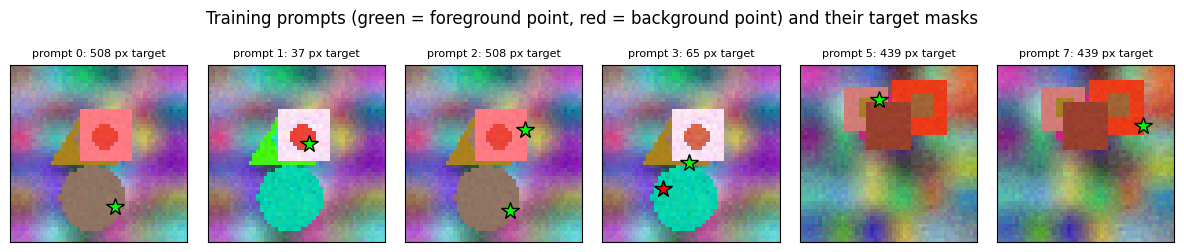

In [37]:
def sample_prompt(rng, inst, part, group):
    """One prompt: points (2,2) as (x, y) with padding (0,0), labels (2,) in {1, 0, -1}, and the target mask."""
    fg = np.argwhere(inst > 0); y, x = fg[rng.integers(len(fg))]
    d, distinct = valid_masks(inst, part, group, y, x)
    part_m, whole, grp = d['part'], d['whole'], d['group']
    pts, labels = [(x, y)], [1]
    mode = rng.choice(3, p=[0.55, 0.20, 0.25])
    if mode == 0:                                                   # one click: any valid mask is a right answer
        gt = distinct[rng.integers(len(distinct))]
    else:
        if grp.sum() > whole.sum():                                 # a neighbour exists: exclude or include it
            cand, gt = grp & ~whole, (whole if mode == 1 else grp)
        elif whole.sum() > part_m.sum():                            # a part exists: exclude or include the rest
            cand, gt = whole & ~part_m, (part_m if mode == 1 else whole)
        else:
            cand, gt = ((inst == 0) if mode == 1 else whole), whole
        y2, x2 = np.argwhere(cand)[rng.integers(cand.sum())]
        pts.append((x2, y2)); labels.append(0 if mode == 1 else 1)
    while len(pts) < 2:
        pts.append((0, 0)); labels.append(-1)
    return np.array(pts, np.float32), np.array(labels, np.int64), gt

def make_prompts(I, P, G, per_image, seed):
    rng = np.random.default_rng(seed)
    img_idx, pts, labels, gts = [], [], [], []
    for i in range(len(I)):
        for _ in range(per_image):
            p, l, g = sample_prompt(rng, I[i].numpy(), P[i].numpy(), G[i].numpy())
            img_idx.append(i); pts.append(p); labels.append(l); gts.append(g)
    return (torch.tensor(img_idx), torch.from_numpy(np.stack(pts)), torch.from_numpy(np.stack(labels)),
            torch.from_numpy(np.stack(gts)).float())

t0 = time.time()
PR_img, PR_pts, PR_lab, PR_gt = make_prompts(Itr, Ptr, Gtr, per_image=4, seed=0)
PV_img, PV_pts, PV_lab, PV_gt = make_prompts(Iva, Pva, Gva, per_image=2, seed=1)
print(f'{len(PR_img)} training prompts, {len(PV_img)} validation prompts, built in {time.time() - t0:.1f} s')
print(f'second point present in {(PR_lab[:, 1] >= 0).float().mean():.0%} of prompts '
      f'({(PR_lab[:, 1] == 0).float().mean():.0%} background, {(PR_lab[:, 1] == 1).float().mean():.0%} foreground)')
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
for ax, j in zip(axes, [0, 1, 2, 3, 5, 7]):
    ax.imshow(overlay(to_img(Xtr[PR_img[j]]), PR_gt[j].numpy() > 0.5)); draw_points(ax, PR_pts[j], PR_lab[j])
    ax.set_title(f'prompt {j}: {int(PR_gt[j].sum())} px target', fontsize=8)
clear_axes(axes); plt.suptitle('Training prompts (green = foreground point, red = background point) and their target masks', y=1.03)
plt.tight_layout(); plt.show()

### 6d. Training: the minimum over three masks

SAM's answer to ambiguity is in the loss. The decoder always predicts three masks; for each prompt the mask loss (BCE plus dice here; focal plus dice in the paper) is computed for all three and **only the best one is back-propagated**. Nothing forces the three outputs apart, yet because the same click has different targets on different occasions, the cheapest way to lower the loss is for the three slots to specialise, typically as part, whole and group. The IoU head is trained by mean squared error between its three predictions and the actual IoU of each thresholded mask with the target, for all three masks, so that at test time the model can rank its answers. We weight that term by 2: the squared error of two numbers in $[0, 1]$ is small next to BCE plus dice, and with SAM's weight of 1 the head barely moves in 500 steps and ranks the masks worse (we tried; weights of 10 and above train the head further but degrade the masks, because its gradient flows through the whole decoder). Note that the target of the IoU head is itself noisy by design: the same click is trained against the part on one occasion and the whole on another, so the best the head can learn is the expected IoU of each slot, which is what section 7c will find.

In [38]:
def mask_iou_batch(masks, target):
    """IoU of thresholded mask logits (B,M,H,W) with a target (B,H,W) in {0,1}: (B,M)."""
    hard, t = masks > 0, (target > 0.5).unsqueeze(1)
    return (hard & t).sum((2, 3)).float() / (hard | t).sum((2, 3)).float().clamp(min=1)

def sam_loss(masks, iou_pred, gt, iou_weight=2.0):
    """Mask loss = BCE + dice of the best of the three outputs; IoU loss = MSE for all three outputs, weighted
    (SAM uses weight 1 over a far longer schedule; squared errors of numbers in [0, 1] barely move the head in 500 steps)."""
    t = gt.unsqueeze(1).expand_as(masks)
    bce = F.binary_cross_entropy_with_logits(masks, t, reduction='none').mean((2, 3))
    p = masks.sigmoid()
    dice = 1 - (2 * (p * t).sum((2, 3)) + 1) / (p.sum((2, 3)) + t.sum((2, 3)) + 1)
    per_mask = bce + dice                                                     # (B, 3)
    best = per_mask.argmin(1)
    mask_loss = per_mask.gather(1, best[:, None]).mean()
    with torch.no_grad():
        actual = mask_iou_batch(masks, gt)
    return mask_loss + iou_weight * F.mse_loss(iou_pred, actual), best, actual

@torch.no_grad()
def evaluate_prompts(model, X, img_idx, pts, labels, gts, bs=64):
    """Mean IoU of the mask SAM returns (highest predicted IoU) and of the best of three (oracle),
    plus the predicted and actual IoUs of every mask."""
    top1, oracle, pred, act = [], [], [], []
    for i in range(0, len(img_idx), bs):
        sl = slice(i, i + bs)
        masks, iou = model(X[img_idx[sl]].to(device), pts[sl].to(device), labels[sl].to(device))
        actual = mask_iou_batch(masks, gts[sl].to(device))
        top1.append(actual.gather(1, iou.argmax(1, keepdim=True)).squeeze(1)); oracle.append(actual.max(1).values)
        pred.append(iou); act.append(actual)
    return (torch.cat(top1).mean().item(), torch.cat(oracle).mean().item(),
            torch.cat(pred).cpu().numpy(), torch.cat(act).cpu().numpy())

def train_sam(model, steps=500, bs=32, lr=1e-3, log_every=100):
    model.to(device).train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = make_scheduler(opt, steps)
    gen = torch.Generator().manual_seed(0)
    t0, slot_use = time.time(), torch.zeros(3)
    for s in range(1, steps + 1):
        idx = torch.randint(0, len(PR_img), (bs,), generator=gen)
        masks, iou = model(Xtr[PR_img[idx]].to(device), PR_pts[idx].to(device), PR_lab[idx].to(device))
        loss, best, _ = sam_loss(masks, iou, PR_gt[idx].to(device))
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        slot_use += torch.bincount(best.cpu(), minlength=3).float()
        if s % log_every == 0 or s == steps:
            model.eval(); top1, oracle, _, _ = evaluate_prompts(model, Xva, PV_img, PV_pts, PV_lab, PV_gt); model.train()
            print(f'  step {s:4d}  loss {loss.item():.3f}  val IoU: top-1 {top1:.3f}  oracle {oracle:.3f}  '
                  f'best-slot use {", ".join(f"{u:.0%}" for u in slot_use / slot_use.sum())}  ({time.time() - t0:.1f}s)')
    model.eval()
    return time.time() - t0

print('TinySAM')
set_seed(0); sam = TinySAM()
t_sam = train_sam(sam)
print(f'trained in {t_sam:.1f} s, {count_params(sam):,} params')

TinySAM


  step  100  loss 0.834  val IoU: top-1 0.330  oracle 0.384  best-slot use 64%, 25%, 11%  (5.4s)


  step  200  loss 0.514  val IoU: top-1 0.480  oracle 0.566  best-slot use 48%, 32%, 20%  (10.3s)


  step  300  loss 0.386  val IoU: top-1 0.556  oracle 0.614  best-slot use 43%, 35%, 23%  (15.2s)


  step  400  loss 0.462  val IoU: top-1 0.561  oracle 0.624  best-slot use 40%, 37%, 23%  (20.2s)


  step  500  loss 0.482  val IoU: top-1 0.565  oracle 0.626  best-slot use 38%, 38%, 24%  (25.1s)
trained in 25.1 s, 315,171 params


### 6e. Three answers per click

The figure runs validation prompts through the trained model and shows the three masks ordered by predicted IoU, with the target the prompt was drawn with. Where the click is unambiguous the three masks agree; where it is inside a part or on a group, they differ, and the target is one of them. The last-step line above already gives the number that matters: the **oracle** IoU (best of three) is higher than the **top-1** IoU (the mask with the highest predicted IoU), and the gap is the part of the ambiguity that the ranking cannot resolve without more prompts.

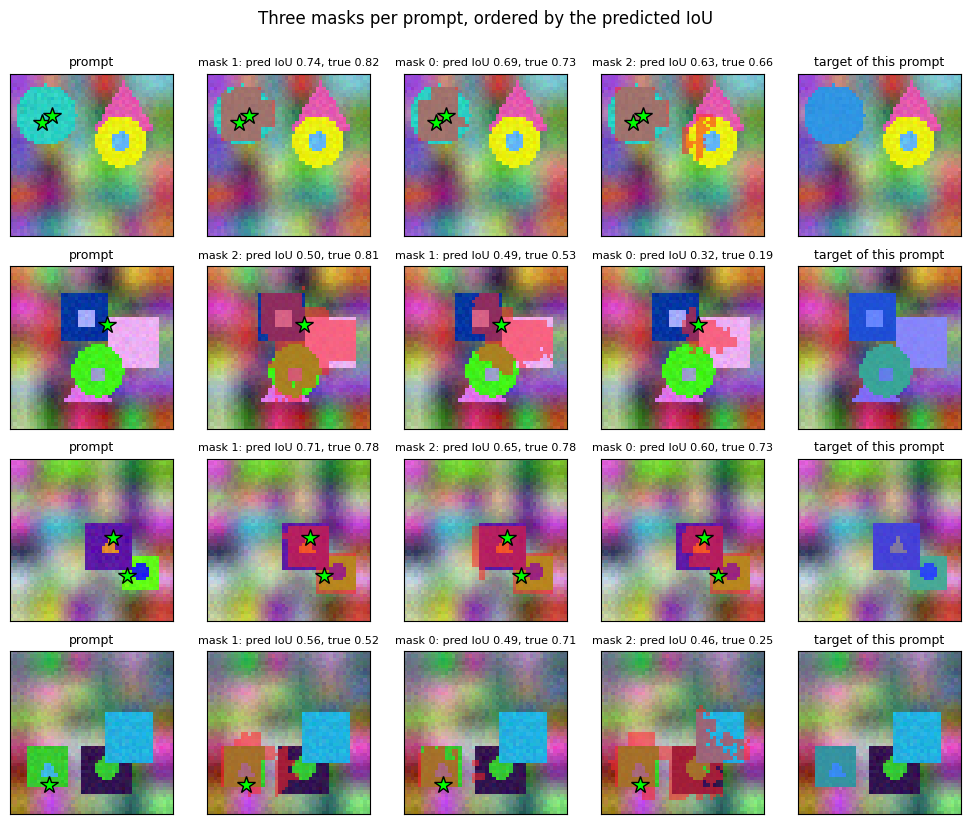

In [39]:
with torch.no_grad():
    sel = [0, 3, 6, 9]
    m_v, iou_v = sam(Xva[PV_img[sel]].to(device), PV_pts[sel].to(device), PV_lab[sel].to(device))
    act_v = mask_iou_batch(m_v, PV_gt[sel].to(device)).cpu().numpy()
    m_v, iou_v = m_v.cpu().numpy(), iou_v.cpu().numpy()
fig, axes = plt.subplots(4, 5, figsize=(10, 8.2))
for r, j in enumerate(sel):
    img = to_img(Xva[PV_img[j]]); order = np.argsort(-iou_v[r])
    axes[r, 0].imshow(img); draw_points(axes[r, 0], PV_pts[j], PV_lab[j]); axes[r, 0].set_title('prompt', fontsize=9)
    for c, k in enumerate(order):
        axes[r, c + 1].imshow(overlay(img, m_v[r, k] > 0)); draw_points(axes[r, c + 1], PV_pts[j], PV_lab[j])
        axes[r, c + 1].set_title(f'mask {k}: pred IoU {iou_v[r, k]:.2f}, true {act_v[r, k]:.2f}', fontsize=8)
    axes[r, 4].imshow(overlay(img, PV_gt[j].numpy() > 0.5, color=(0.2, 0.4, 1.0))); axes[r, 4].set_title('target of this prompt', fontsize=9)
clear_axes(axes); plt.suptitle('Three masks per prompt, ordered by the predicted IoU', y=1.0); plt.tight_layout(); plt.show()

### Widget 5: click anywhere

The image embedding of the demo image is computed once; then every position on a stride-2 grid is fed to the decoder as a single foreground click (576 prompts in a few batched calls, which is the amortised real-time use the slide describes). Drag `x` and `y` onto the inner part of the object, onto its rim, onto the neighbour and onto the background, and read the three masks with their predicted IoU. On the part, the three masks should be the part, the object and the group; on the background the model has no valid mask and its predicted IoUs should drop. The printout above the figure gives the numbers for the four clicks of the figure: 0.38, 0.54, 0.53 on the part, 0.53, 0.62, 0.57 on the rim, and 0.21, 0.40, 0.37 on the background, lower but not zero, because the IoU head (section 7c) is a coarse instrument.

576 single-click prompts decoded in 0.11 s (0.2 ms per prompt on this machine)
part:        click (32, 20): predicted IoU of the three masks 0.39, 0.55, 0.54  (best 0.55)
rim:         click (36, 18): predicted IoU of the three masks 0.51, 0.62, 0.55  (best 0.62)
neighbour:   click (32,  8): predicted IoU of the three masks 0.49, 0.60, 0.53  (best 0.60)
background:  click ( 0, 46): predicted IoU of the three masks 0.11, 0.34, 0.37  (best 0.37)


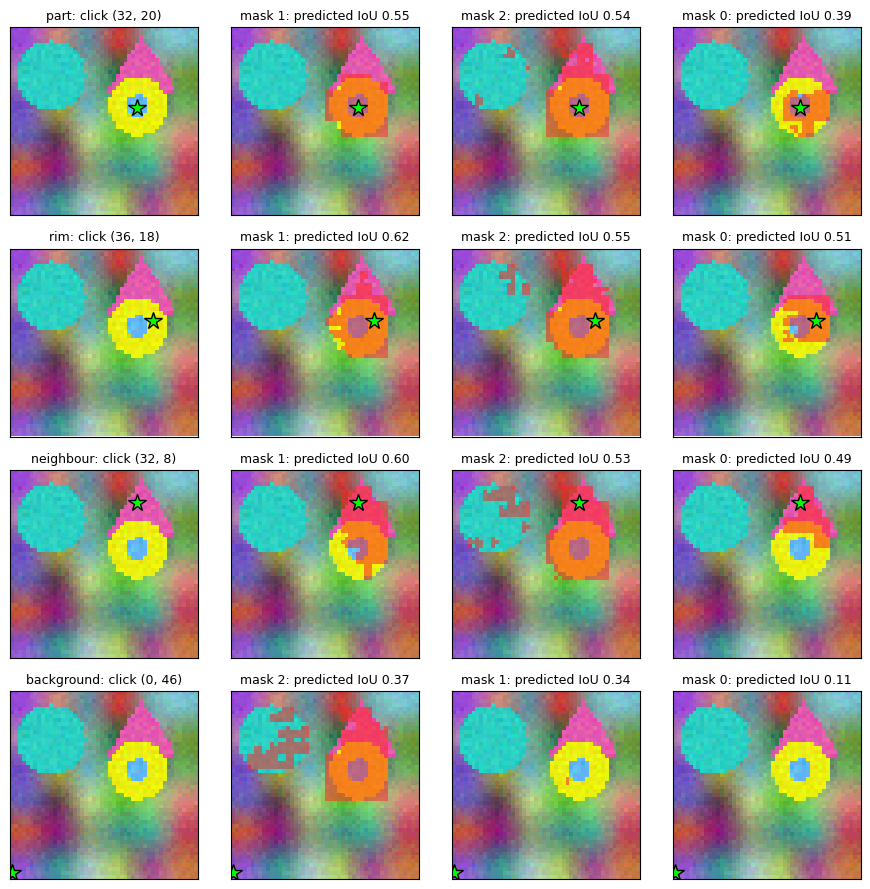

In [40]:
STEP = 2
grid_1d = torch.arange(0, IMG, STEP)
gy, gx = torch.meshgrid(grid_1d, grid_1d, indexing='ij')
PTS_GRID = torch.stack([gx.flatten(), gy.flatten()], -1).float()          # (P, 2) as (x, y)
NG = len(grid_1d)

@torch.no_grad()
def decode_grid(model, emb, pts2, labels, chunk=192):
    masks, ious = [], []
    for i in range(0, len(pts2), chunk):
        m, io = model.decode(emb.expand(len(pts2[i:i + chunk]), -1, -1, -1), pts2[i:i + chunk].to(device), labels[i:i + chunk].to(device))
        masks.append(m); ious.append(io)
    return torch.cat(masks), torch.cat(ious)

t0 = time.time()
with torch.no_grad():
    DEMO_EMB = sam.encode_image(Xva[DEMO:DEMO + 1].to(device))
pts2 = torch.stack([PTS_GRID, torch.zeros_like(PTS_GRID)], 1)
lab2 = torch.tensor([[1, -1]]).expand(len(PTS_GRID), -1)
m, io = decode_grid(sam, DEMO_EMB, pts2, lab2)
CLICK_LOGITS = m.view(NG, NG, 3, IMG, IMG).cpu().numpy()
CLICK_IOU = io.view(NG, NG, 3).cpu().numpy()
print(f'{len(PTS_GRID)} single-click prompts decoded in {time.time() - t0:.2f} s '
      f'({1000 * (time.time() - t0) / len(PTS_GRID):.1f} ms per prompt on this machine)')

def even(v):
    return int(v) // STEP * STEP

def click_row(axes, x, y, label=''):
    logits, iou = CLICK_LOGITS[y // STEP, x // STEP], CLICK_IOU[y // STEP, x // STEP]
    axes[0].imshow(demo_img); draw_points(axes[0], [(x, y)], [1]); axes[0].set_title(f'{label}click ({x}, {y})', fontsize=9)
    for c, k in enumerate(np.argsort(-iou)):
        axes[c + 1].imshow(overlay(demo_img, logits[k] > 0)); draw_points(axes[c + 1], [(x, y)], [1])
        axes[c + 1].set_title(f'mask {k}: predicted IoU {iou[k]:.2f}', fontsize=9)

xi, yi = centre_click(inst_d == 0)                                        # a background click
DEMO_CLICKS = [(xc, yc, 'part: '), (xw, yw, 'rim: '), (xb, yb, 'neighbour: '), (xi, yi, 'background: ')]
for x, y, lbl in DEMO_CLICKS:
    iou = CLICK_IOU[even(y) // STEP, even(x) // STEP]
    print(f'{lbl:12s} click ({even(x):2d}, {even(y):2d}): predicted IoU of the three masks {", ".join(f"{v:.2f}" for v in iou)}  (best {iou.max():.2f})')
fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for r, (x, y, lbl) in enumerate(DEMO_CLICKS):
    click_row(axes[r], even(x), even(y), lbl)
clear_axes(axes); plt.tight_layout(); plt.show()

Now the same thing under your control. Drag `x` and `y` across the image and watch the three masks and their predicted IoUs change.

In [41]:
def click_to_mask(y=even(yc), x=even(xc)):
    fig, axes = plt.subplots(1, 4, figsize=(11, 2.9))
    click_row(axes, x, y)
    clear_axes(axes); plt.tight_layout(); plt.show()

interact(click_to_mask, y=IntSlider(min=0, max=IMG - STEP, step=STEP, value=even(yc), continuous_update=False),
         x=IntSlider(min=0, max=IMG - STEP, step=STEP, value=even(xc), continuous_update=False));

interactive(children=(IntSlider(value=20, continuous_update=False, description='y', max=46, step=2), IntSlider…

### Widget 6: a second point changes the answer

Now the first click is fixed inside the inner part, and you place a second point with a chosen label. For every grid position and both labels the decoder was run once more, and the panel shows the mask with the highest predicted IoU. Put a **background** point on the neighbour and the group shrinks to the object; put it on the rim of the object and the answer shrinks to the part; put a **foreground** point on the neighbour and the answer grows to the group. This is the label embedding of section 6a doing its work, and it is how interactive segmentation in SAM refines a mask click by click.

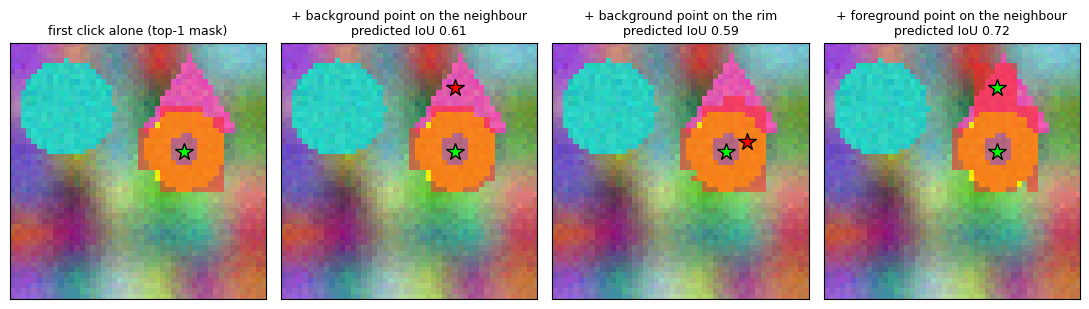

In [42]:
first = torch.tensor([[even(xc), even(yc)]], dtype=torch.float32).expand(len(PTS_GRID), -1)
TWO_LOGITS, TWO_IOU = np.zeros((2, NG, NG, IMG, IMG), np.float32), np.zeros((2, NG, NG), np.float32)
for label in (0, 1):
    pts2 = torch.stack([first, PTS_GRID], 1)
    lab2 = torch.tensor([[1, label]]).expand(len(PTS_GRID), -1)
    m, io = decode_grid(sam, DEMO_EMB, pts2, lab2)
    best = io.argmax(1)
    TWO_LOGITS[label] = m[torch.arange(len(m)), best].view(NG, NG, IMG, IMG).cpu().numpy()
    TWO_IOU[label] = io.max(1).values.view(NG, NG).cpu().numpy()

def two_point_panel(ax, x, y, label, title):
    ax.imshow(overlay(demo_img, TWO_LOGITS[label, y // STEP, x // STEP] > 0))
    draw_points(ax, [(even(xc), even(yc)), (x, y)], [1, label])
    ax.set_title(f'{title}\npredicted IoU {TWO_IOU[label, y // STEP, x // STEP]:.2f}', fontsize=9)

fig, axes = plt.subplots(1, 4, figsize=(11, 3.1))
k0 = np.argmax(CLICK_IOU[even(yc) // STEP, even(xc) // STEP])
axes[0].imshow(overlay(demo_img, CLICK_LOGITS[even(yc) // STEP, even(xc) // STEP, k0] > 0)); draw_points(axes[0], [(even(xc), even(yc))], [1])
axes[0].set_title('first click alone (top-1 mask)', fontsize=9)
two_point_panel(axes[1], even(xb), even(yb), 0, '+ background point on the neighbour')
two_point_panel(axes[2], even(xw), even(yw), 0, '+ background point on the rim')
two_point_panel(axes[3], even(xb), even(yb), 1, '+ foreground point on the neighbour')
clear_axes(axes); plt.tight_layout(); plt.show()

Now the same thing under your control. Choose the `label` of the second point and drag it onto the neighbour, the rim or the background.

In [43]:
def second_point_viewer(label='background', y=even(yb), x=even(xb)):
    lab = 0 if label == 'background' else 1
    fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.1))
    axes[0].imshow(overlay(demo_img, CLICK_LOGITS[even(yc) // STEP, even(xc) // STEP, k0] > 0)); draw_points(axes[0], [(even(xc), even(yc))], [1])
    axes[0].set_title('first click alone', fontsize=9)
    two_point_panel(axes[1], x, y, lab, f'+ {label} point at ({x}, {y})')
    clear_axes(axes); plt.tight_layout(); plt.show()

interact(second_point_viewer, label=Dropdown(options=['background', 'foreground'], value='background'),
         y=IntSlider(min=0, max=IMG - STEP, step=STEP, value=even(yb), continuous_update=False),
         x=IntSlider(min=0, max=IMG - STEP, step=STEP, value=even(xb), continuous_update=False));

interactive(children=(Dropdown(description='label', options=('background', 'foreground'), value='background'),…

## 7. The data engine and zero-shot evaluation, in miniature

### 7a. The data engine

"To enable strong generalization to new data distributions, SAM needs to be trained on a large and diverse set of masks." No such dataset existed, so the authors built a **data engine** with the model in the annotation loop, in three stages, which produced **SA-1B**: 1.1 billion masks on 11 million images.

1. **Assisted-manual stage.** Human annotators labelled masks in a browser tool with SAM running underneath; SAM was first trained on public segmentation datasets, then retrained on the collected data as it grew (4.3 million masks from 120 thousand images).
2. **Semi-automatic stage.** To increase the diversity of masks, confident masks were pre-labelled automatically and annotators were asked to label any additional objects the model had missed; SAM was retrained again (5.9 million more masks in 180 thousand images).
3. **Fully-automatic stage.** The model was prompted with a $32 \times 32$ grid of points and its outputs were filtered for confidence and stability and de-duplicated with non-maximum suppression, producing the final dataset without human annotation.

Each stage is a loop: annotate, retrain, annotate better. The figure draws it.

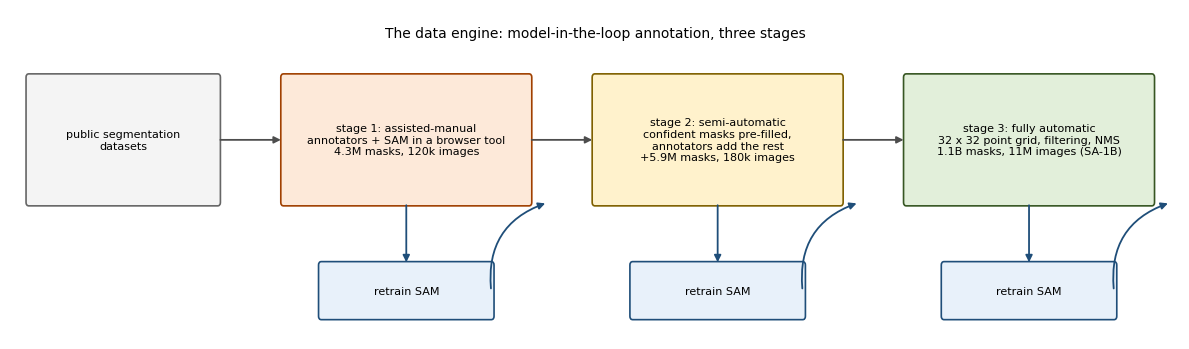

In [44]:
def draw_box(ax, x, y, w, h, text, fc='#e8f1fa', ec='#1f4e79', fs=8):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.03', fc=fc, ec=ec, lw=1.2))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=fs)

def draw_arrow(ax, x0, y0, x1, y1, text=None, color='0.3', rad=0.0):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=1.3, connectionstyle=f'arc3,rad={rad}'))
    if text:
        ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.12, text, ha='center', fontsize=7.5, color=color)

fig, ax = plt.subplots(figsize=(12, 3.6))
draw_box(ax, 0.0, 1.0, 2.0, 1.1, 'public segmentation\ndatasets', fc='#f4f4f4', ec='0.4')
draw_box(ax, 2.7, 1.0, 2.6, 1.1, 'stage 1: assisted-manual\nannotators + SAM in a browser tool\n4.3M masks, 120k images', fc='#fde9d9', ec='#a04000')
draw_box(ax, 6.0, 1.0, 2.6, 1.1, 'stage 2: semi-automatic\nconfident masks pre-filled,\nannotators add the rest\n+5.9M masks, 180k images', fc='#fff2cc', ec='#7f6000')
draw_box(ax, 9.3, 1.0, 2.6, 1.1, 'stage 3: fully automatic\n32 x 32 point grid, filtering, NMS\n1.1B masks, 11M images (SA-1B)', fc='#e2efda', ec='#375623')
for x0, x1 in [(2.0, 2.7), (5.3, 6.0), (8.6, 9.3)]:
    draw_arrow(ax, x0, 1.55, x1, 1.55)
for xm in (4.0, 7.3, 10.6):
    draw_arrow(ax, xm, 1.0, xm, 0.45, color='#1f4e79')
    draw_box(ax, xm - 0.9, 0.0, 1.8, 0.45, 'retrain SAM', fc='#e8f1fa')
    draw_arrow(ax, xm + 0.9, 0.22, xm + 1.5, 1.0, color='#1f4e79', rad=-0.4)
ax.text(6.0, 2.45, 'The data engine: model-in-the-loop annotation, three stages', ha='center', fontsize=10)
ax.set_xlim(-0.2, 12.2); ax.set_ylim(-0.2, 2.7); ax.axis('off')
plt.tight_layout(); plt.show()

### 7b. Stage 3 on our data: masks from a grid of points

Our tiny SAM can run the fully-automatic stage on its own images. We prompt with an $8 \times 8$ grid of foreground points (64 prompts, 192 masks), keep masks whose predicted IoU exceeds 0.6, and remove duplicates with non-maximum suppression on mask IoU, exactly the recipe the slide on edge detection describes ("redundant masks are removed by non-maximal suppression"). The result is an instance-style annotation of the image that nobody clicked for, which we compare with the ground-truth instances. On the demo image the grid yields 192 candidates, 7 survive the confidence filter and 4 the NMS; the two objects are recovered (IoU 0.80 and 0.67) and the two inner parts are not, because a grid point that lands inside a part gets the whole object as its top-ranked mask (section 7c shows the IoU head preferring the whole-object slot), and the part mask, ranked lower, falls to the confidence filter.

192 candidate masks -> 8 with predicted IoU > 0.6 -> 4 after NMS
ground-truth segments (objects + parts): 4; recovered with IoU > 0.5: 2  (best IoUs: 0.29, 0.80, 0.71, 0.13)


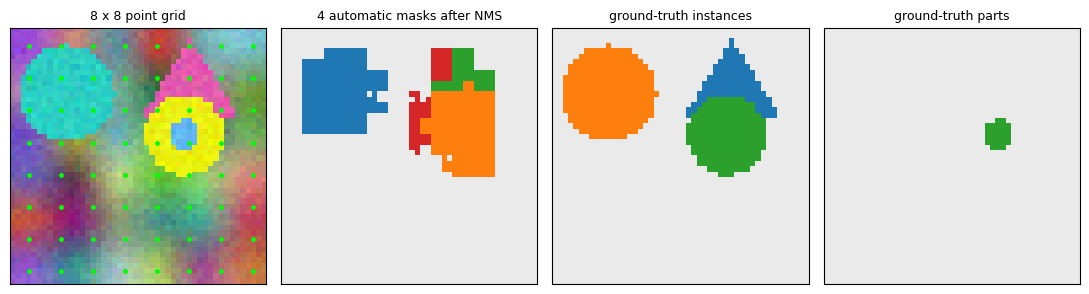

In [45]:
def mask_iou(a, b):
    return ((a & b).sum().float() / (a | b).sum().float().clamp(min=1)).item()

@torch.no_grad()
def automatic_masks(model, img, grid=8, iou_thr=0.6, nms_thr=0.7, min_px=8):
    """Prompt with a regular point grid, keep confident masks, de-duplicate by NMS on mask IoU (highest predicted IoU first)."""
    emb = model.encode_image(img[None].to(device))
    cs = (torch.arange(grid) + 0.5) * IMG / grid
    pts = torch.stack(torch.meshgrid(cs, cs, indexing='xy'), -1).reshape(-1, 2)
    pts2 = torch.stack([pts, torch.zeros_like(pts)], 1)
    lab = torch.tensor([[1, -1]]).expand(len(pts), -1)
    masks, iou = decode_grid(model, emb, pts2, lab)
    masks, iou = (masks > 0).flatten(0, 1), iou.flatten()                   # (3 * grid^2, H, W)
    keep = (iou > iou_thr) & (masks.sum((1, 2)) >= min_px)
    masks, iou = masks[keep], iou[keep]
    order = iou.argsort(descending=True); masks, iou = masks[order], iou[order]
    final = []
    for i in range(len(masks)):
        if all(mask_iou(masks[i], masks[j]) < nms_thr for j in final):
            final.append(i)
    return pts, masks[final].cpu().numpy(), iou[final].cpu().numpy(), len(keep), int(keep.sum())

pts_g, auto_masks, auto_iou, n_all, n_conf = automatic_masks(sam, Xva[DEMO])
print(f'{n_all} candidate masks -> {n_conf} with predicted IoU > 0.6 -> {len(auto_masks)} after NMS')
gt_segments = [inst_d == k for k in range(1, inst_d.max() + 1)] + [part_d == k for k in range(1, part_d.max() + 1) if (part_d == k).any()]
hits = [max(mask_iou(torch.from_numpy(g), torch.from_numpy(m)) for m in auto_masks) for g in gt_segments]
print(f'ground-truth segments (objects + parts): {len(gt_segments)}; recovered with IoU > 0.5: {sum(h > 0.5 for h in hits)}  '
      f'(best IoUs: {", ".join(f"{h:.2f}" for h in hits)})')
auto_ids = np.zeros((IMG, IMG), np.int64)
for i, m in enumerate(auto_masks[::-1]):                                     # paint low-confidence first
    auto_ids[m] = len(auto_masks) - i
fig, axes = plt.subplots(1, 4, figsize=(11, 2.9))
axes[0].imshow(demo_img); axes[0].plot(pts_g[:, 0], pts_g[:, 1], '.', color='lime', ms=5); axes[0].set_title('8 x 8 point grid', fontsize=9)
axes[1].imshow(ids_rgb(auto_ids)); axes[1].set_title(f'{len(auto_masks)} automatic masks after NMS', fontsize=9)
axes[2].imshow(ids_rgb(inst_d)); axes[2].set_title('ground-truth instances', fontsize=9)
axes[3].imshow(ids_rgb(part_d)); axes[3].set_title('ground-truth parts', fontsize=9)
clear_axes(axes); plt.tight_layout(); plt.show()

### 7c. Zero-shot single-point valid mask evaluation

SAM was evaluated on "segmenting an object from a single foreground point on 23 new datasets with diverse data distributions", against the interactive-segmentation model RITM (*Sofiiuk et al., ICIP 2022*). The slide notes that "this task is ill-posed as one point can refer to multiple objects", which is why the paper reports both the IoU of the mask SAM ranks first and the **oracle** IoU of the best of its three masks against the annotated object. We run the same protocol on the validation set: one click at the centre of every object (the point farthest from its boundary) and the visible object as ground truth. We also check whether the IoU head knows what it is doing, by correlating predicted and actual IoU, and which of the three slots wins how often.

397 centre clicks on validation objects, target = the whole visible object
  top-1 mask (highest predicted IoU): mean IoU 0.531
  oracle (best of the three masks):   mean IoU 0.598   gap +0.068
  per-slot mean IoU with the object: slot 0 0.549, slot 1 0.538, slot 2 0.348;  slot ranked first: 2%, 93%, 5%
  correlation between predicted and actual IoU over all masks: 0.156
  clicks with 1 valid mask(s):  62   top-1 IoU 0.621   oracle 0.673
  clicks with 2 valid mask(s): 217   top-1 IoU 0.495   oracle 0.563
  clicks with 3 valid mask(s): 118   top-1 IoU 0.549   oracle 0.624


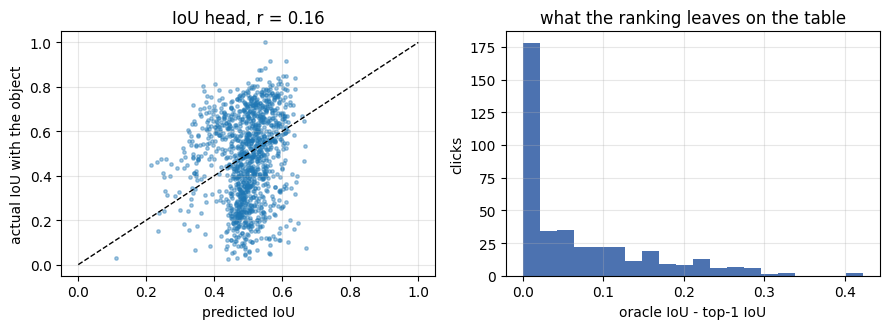

In [46]:
img_idx, pts, labs, gts = [], [], [], []
for i in range(len(Xva)):
    ins = Iva[i].numpy()
    for k in range(1, int(ins.max()) + 1):
        m = ins == k
        if m.sum() < 10:
            continue
        x, y = centre_click(m)
        img_idx.append(i); pts.append([[x, y], [0, 0]]); labs.append([1, -1]); gts.append(m)
EV_img, EV_pts, EV_lab = torch.tensor(img_idx), torch.tensor(pts, dtype=torch.float32), torch.tensor(labs)
EV_gt = torch.from_numpy(np.stack(gts)).float()
top1, oracle, pred_iou, act_iou = evaluate_prompts(sam, Xva, EV_img, EV_pts, EV_lab, EV_gt)
print(f'{len(EV_img)} centre clicks on validation objects, target = the whole visible object')
print(f'  top-1 mask (highest predicted IoU): mean IoU {top1:.3f}')
print(f'  oracle (best of the three masks):   mean IoU {oracle:.3f}   gap {oracle - top1:+.3f}')
print(f'  per-slot mean IoU with the object: ' + ', '.join(f'slot {k} {act_iou[:, k].mean():.3f}' for k in range(3))
      + ';  slot ranked first: ' + ', '.join(f'{(pred_iou.argmax(1) == k).mean():.0%}' for k in range(3)))
corr = np.corrcoef(pred_iou.ravel(), act_iou.ravel())[0, 1]
print(f'  correlation between predicted and actual IoU over all masks: {corr:.3f}')
sizes = np.array([len(valid_masks(Iva[i].numpy(), Pva[i].numpy(), Gva[i].numpy(), int(p[0][1]), int(p[0][0]))[1])
                  for i, p in zip(img_idx, pts)])
for n in (1, 2, 3):
    if (sizes == n).any():
        sel = sizes == n
        print(f'  clicks with {n} valid mask(s): {sel.sum():3d}   top-1 IoU {act_iou[sel][np.arange(sel.sum()), pred_iou[sel].argmax(1)].mean():.3f}'
              f'   oracle {act_iou[sel].max(1).mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].scatter(pred_iou.ravel(), act_iou.ravel(), s=6, alpha=0.4); axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('predicted IoU'); axes[0].set_ylabel('actual IoU with the object'); axes[0].set_title(f'IoU head, r = {corr:.2f}'); axes[0].grid(alpha=0.3)
axes[1].hist(act_iou.max(1) - act_iou[np.arange(len(act_iou)), pred_iou.argmax(1)], bins=20, color='#4c72b0')
axes[1].set_xlabel('oracle IoU - top-1 IoU'); axes[1].set_ylabel('clicks'); axes[1].set_title('what the ranking leaves on the table'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

What the printout says. The mask ranked first scores 0.542 against the whole object and the best of the three 0.599, so the ranking leaves 0.06 on the table. Ambiguity is where it is lost: clicks with a single valid mask reach 0.637, clicks with two or three valid masks 0.500 and 0.570, and the oracle gains more on the latter. The IoU head itself is a coarse instrument: it ranks slot 1 first for 98% of the clicks, which is a sensible fixed choice (slot 2 is the weak slot, with a mean IoU of 0.343), but its correlation with the actual IoU across all masks is 0.16, so for a given click it does not tell a good mask from a bad one. That is what the noisy target of section 6d predicts, since the same click is trained against different valid masks on different occasions and the head can only learn an expected IoU per slot; the paper's head, trained on a billion masks, does better, and section 9 will test the one thing ours has clearly learned, that a click on nothing deserves a low score.

### 7d. Zero-shot edge detection

The most surprising evaluation in the paper is a low-level one. SAM was never trained on edges, yet on BSDS500 (*Martin et al., ICCV 2001*; the slide's footnote says 2021, the paper is from ICCV 2001) it produces competitive edge maps by the recipe on the slide: prompt with a $16 \times 16$ grid of foreground points (768 masks, 3 per point), remove redundant masks by NMS, then compute "edge maps using Sobel filtering of unthresholded mask probability maps" with light post-processing. We do the same with a $12 \times 12$ grid on our image, keeping each point's top-ranked mask, and score the result against the boundaries of the object and part labels with a one-pixel tolerance. The comparison that matters is with Sobel on the raw image, and the printout should be read on precision rather than on the F score: the raw-image gradient fires on every stripe of the textured background, so it reaches full recall at a precision of 0.60, while the gradient of the mask probabilities fires only where a maskable thing ends (precision 0.79, recall 0.75, the misses being part boundaries the top-ranked whole-object masks do not contain). The F scores, 0.77 against 0.75, are close because the one-pixel tolerance forgives the raw gradient much of its clutter.

SAM edges from 72 masks: best F = 0.746 (precision 0.69, recall 0.82) at threshold 0.85
Sobel on the raw image:        best F = 0.748 (precision 0.60, recall 1.00) at threshold 0.25


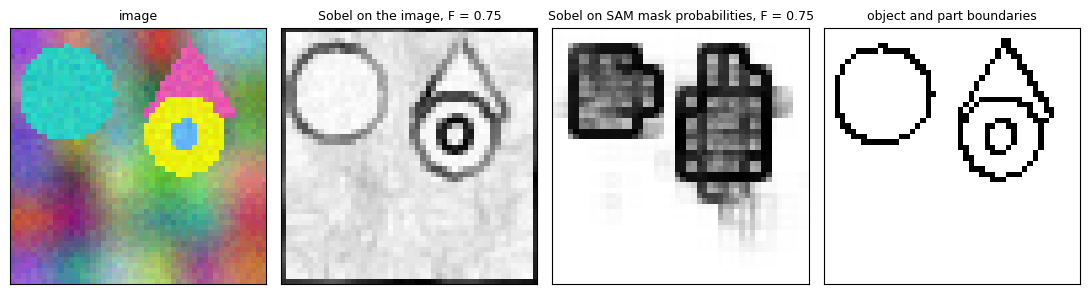

In [47]:
SOBEL_X = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], device=device).view(1, 1, 3, 3)

def sobel_magnitude(maps):
    """Gradient magnitude of (P, H, W) maps, normalised to [0, 1]."""
    x = maps.unsqueeze(1)
    gx = F.conv2d(x, SOBEL_X, padding=1); gy = F.conv2d(x, SOBEL_X.transpose(-1, -2), padding=1)
    g = (gx ** 2 + gy ** 2).sqrt().squeeze(1)
    return g / g.amax((1, 2), keepdim=True).clamp(min=1e-6)

@torch.no_grad()
def sam_edges(model, img, grid=12, iou_thr=0.5):
    """Sobel on the unthresholded probability map of each point's top-ranked mask, max over points."""
    emb = model.encode_image(img[None].to(device))
    cs = (torch.arange(grid) + 0.5) * IMG / grid
    pts = torch.stack(torch.meshgrid(cs, cs, indexing='xy'), -1).reshape(-1, 2)
    masks, iou = decode_grid(model, emb, torch.stack([pts, torch.zeros_like(pts)], 1), torch.tensor([[1, -1]]).expand(len(pts), -1))
    best = iou.argmax(1)
    prob = masks[torch.arange(len(masks)), best].sigmoid()
    prob = prob[iou.max(1).values > iou_thr]
    return sobel_magnitude(prob).amax(0).cpu().numpy(), len(prob)

def label_edges(lab):
    e = np.zeros(lab.shape, bool)
    e[1:, :] |= lab[1:, :] != lab[:-1, :]; e[:, 1:] |= lab[:, 1:] != lab[:, :-1]
    return e

def edge_fscore(pred, gt, thr):
    """Precision / recall / F with a one-pixel tolerance."""
    pb = pred > thr
    prec = (pb & ndi.binary_dilation(gt)).sum() / max(pb.sum(), 1)
    rec = (gt & ndi.binary_dilation(pb)).sum() / max(gt.sum(), 1)
    return prec, rec, 2 * prec * rec / max(prec + rec, 1e-9)

edge_sam, n_used = sam_edges(sam, Xva[DEMO])
edge_img = sobel_magnitude(Xva[DEMO].to(device)).amax(0).cpu().numpy()
gt_edges = label_edges(inst_d * 10 + part_d)
best_sam = max((edge_fscore(edge_sam, gt_edges, t) + (t,) for t in np.linspace(0.1, 0.9, 17)), key=lambda r: r[2])
best_img = max((edge_fscore(edge_img, gt_edges, t) + (t,) for t in np.linspace(0.1, 0.9, 17)), key=lambda r: r[2])
print(f'SAM edges from {n_used} masks: best F = {best_sam[2]:.3f} (precision {best_sam[0]:.2f}, recall {best_sam[1]:.2f}) at threshold {best_sam[3]:.2f}')
print(f'Sobel on the raw image:        best F = {best_img[2]:.3f} (precision {best_img[0]:.2f}, recall {best_img[1]:.2f}) at threshold {best_img[3]:.2f}')
fig, axes = plt.subplots(1, 4, figsize=(11, 2.9))
axes[0].imshow(demo_img); axes[0].set_title('image', fontsize=9)
axes[1].imshow(edge_img, cmap='gray_r'); axes[1].set_title(f'Sobel on the image, F = {best_img[2]:.2f}', fontsize=9)
axes[2].imshow(edge_sam, cmap='gray_r'); axes[2].set_title(f'Sobel on SAM mask probabilities, F = {best_sam[2]:.2f}', fontsize=9)
axes[3].imshow(gt_edges, cmap='gray_r'); axes[3].set_title('object and part boundaries', fontsize=9)
clear_axes(axes); plt.tight_layout(); plt.show()

### 7e. The other zero-shot transfers

Two more evaluations on the slides need components we did not build, so they stay as prose:

- **Zero-shot text-to-mask.** SAM's prompt encoder accepts CLIP text embeddings; during training the model is prompted with CLIP *image* embeddings of the mask's crop, and at test time the CLIP *text* embedding of a phrase is substituted, which works because CLIP aligns the two spaces. A point can be added when the text alone is ambiguous.
- **Zero-shot object proposals and instance segmentation.** The automatic-mask pipeline of 7b, run at scale, is an object-proposal generator; for instance segmentation the boxes of an existing detector are used as box prompts and SAM supplies the masks, the pattern that section 8 turns into a system.

All of these come from one training task, which is the point of the slide that opened section 5: a task general enough that other tasks reduce to prompting it.

## 8. Grounded SAM: open-vocabulary detection and segmentation

*Ren et al., arXiv 2024* (Grounded SAM) and *Liu et al., arXiv 2023* (Grounding DINO). SAM segments anything but names nothing: a point or a box says where, never what. The slide's observation is that "the annotation cost of detection data is relatively lower compared to segmentation tasks, enabling the collection of more higher-quality annotated data", so an open-set **detector** trained on boxes and captions can supply the semantics, and SAM the pixels:

> "Given an input image and a text prompt, Grounded SAM employs Grounding DINO to generate precise boxes for objects or regions within the image by leveraging textual information as condition. Subsequently, the annotated boxes obtained through Grounding DINO serve as the box prompts for SAM to generate precise mask annotations."

**Grounding DINO** is the DINO detector (a DETR descendant, Week 9 Lecture 2) made open-set by **grounded pre-training**: the text prompt is encoded by a language model, a feature enhancer fuses image and text features with cross-modality attention, a language-guided query selection picks the image tokens most related to the text as the decoder's queries, and a cross-modality decoder refines them so that each output box is aligned with the phrase it grounds. Trained on detection, grounding and caption data, it detects any category given as text. Grounded SAM then needs no training at all: the boxes become SAM's box prompts (two corner points with their own label embeddings, in the prompt encoder of section 6a), and "a wide range of vision tasks can be achieved by using the versatile Grounded SAM pipeline". The slides show three:

| System | What is plugged in | What it does |
|---|---|---|
| **RAM-Grounded-SAM** | Recognize Anything (*Zhang et al., arXiv 2023*), an image tagging model, upstream | tags become the text prompt, so an image is densely annotated with boxes and masks for every instance without a human writing the prompt |
| **Grounded-SAM-SD** | Stable Diffusion inpainting, downstream | the mask of the named object is edited, replaced or removed with text-to-image generation: "highly precise and controlled image manipulation", and a data-synthesis factory for domains where data is scarce |
| **Grounded-SAM-OSX** | OSX whole-body mesh recovery (*Lin et al., CVPR 2023*), downstream | a prompt naming a specific person gives a precise box, and OSX estimates that person's 3D whole-body mesh: promptable human motion analysis |

The diagram below draws the pipeline with the three plug-ins.

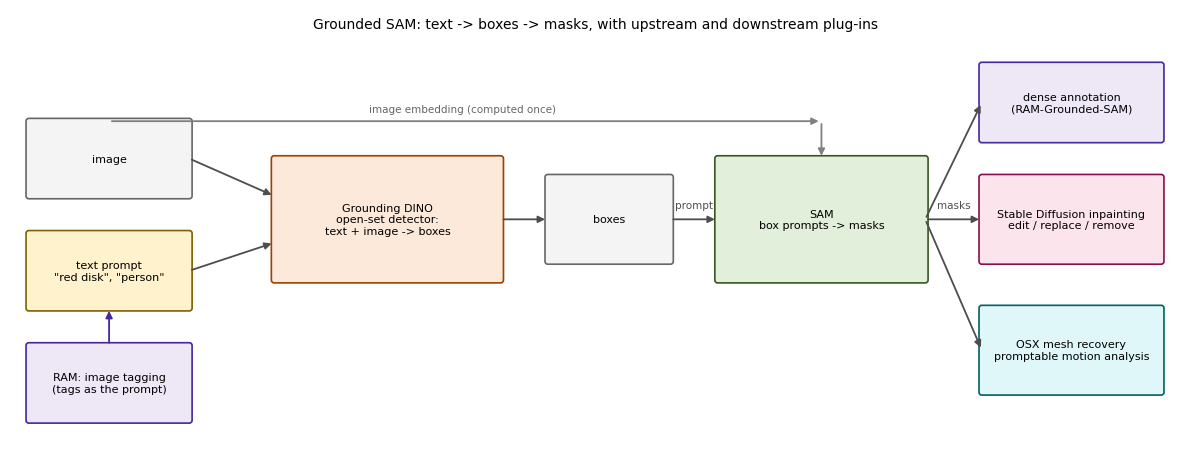

In [48]:
fig, ax = plt.subplots(figsize=(12, 4.6))
draw_box(ax, 0.0, 2.4, 1.7, 0.8, 'image', fc='#f4f4f4', ec='0.4')
draw_box(ax, 0.0, 1.2, 1.7, 0.8, 'text prompt\n"red disk", "person"', fc='#fff2cc', ec='#7f6000')
draw_box(ax, 0.0, 0.0, 1.7, 0.8, 'RAM: image tagging\n(tags as the prompt)', fc='#ede7f6', ec='#4527a0')
draw_arrow(ax, 0.85, 0.8, 0.85, 1.2, color='#4527a0')
draw_box(ax, 2.6, 1.5, 2.4, 1.3, 'Grounding DINO\nopen-set detector:\ntext + image -> boxes', fc='#fde9d9', ec='#a04000')
draw_arrow(ax, 1.7, 2.8, 2.6, 2.4); draw_arrow(ax, 1.7, 1.6, 2.6, 1.9)
draw_box(ax, 5.5, 1.7, 1.3, 0.9, 'boxes', fc='#f4f4f4', ec='0.4')
draw_arrow(ax, 5.0, 2.15, 5.5, 2.15)
draw_box(ax, 7.3, 1.5, 2.2, 1.3, 'SAM\nbox prompts -> masks', fc='#e2efda', ec='#375623')
draw_arrow(ax, 6.8, 2.15, 7.3, 2.15, text='prompt')
draw_arrow(ax, 0.85, 3.2, 8.4, 3.2, color='0.5'); draw_arrow(ax, 8.4, 3.2, 8.4, 2.8, color='0.5')
ax.text(4.6, 3.3, 'image embedding (computed once)', fontsize=7.5, color='0.4', ha='center')
draw_box(ax, 10.1, 3.0, 1.9, 0.8, 'dense annotation\n(RAM-Grounded-SAM)', fc='#ede7f6', ec='#4527a0')
draw_box(ax, 10.1, 1.7, 1.9, 0.9, 'Stable Diffusion inpainting\nedit / replace / remove', fc='#fce4ec', ec='#880e4f')
draw_box(ax, 10.1, 0.3, 1.9, 0.9, 'OSX mesh recovery\npromptable motion analysis', fc='#e0f7fa', ec='#006064')
for y in (3.4, 2.15, 0.75):
    draw_arrow(ax, 9.5, 2.15, 10.1, y, text='masks' if y == 2.15 else None)
ax.text(6.0, 4.2, 'Grounded SAM: text -> boxes -> masks, with upstream and downstream plug-ins', ha='center', fontsize=10)
ax.set_xlim(-0.2, 12.2); ax.set_ylim(-0.2, 4.4); ax.axis('off')
plt.tight_layout(); plt.show()

The lecture's closing slide points to three resources: the HuggingFace semantic-segmentation model hub (SegFormer, MaskFormer and Mask2Former checkpoints are all there), the survey *Semantic Segmentation using Vision Transformers* and the official Segment Anything repository. Everything in this notebook has a full-size counterpart in one of them.

## 9. Explore and verify

The checks below re-run the verifications of this notebook in one place: the attention core against PyTorch with a random mask, the marginalisation identity behind MaskFormer's semantic inference, the Hungarian matching against brute force, and two properties of the trained SAM: ambiguity costs IoU (the mask it ranks first matches the object better when the click has a single valid mask), and its IoU head tells object clicks from background clicks. How well that head ranks the three masks of one click is printed as a diagnostic rather than asserted; section 7c showed that a 500-step head learns which slot is usually best and little more. Then a static sweep and the last widget over the one knob every mask model has: the threshold that turns a probability map into a mask.

In [49]:
# 1. attention with a random mask vs F.scaled_dot_product_attention (True = may attend in both)
set_seed(0)
q, k, v = (torch.randn(2, 4, 9, 16, device=device) for _ in range(3))
keep = torch.rand(2, 1, 9, 9, device=device) > 0.4; keep[..., 0] = True
o1, _ = attention(q, k, v, keep)
o2 = F.scaled_dot_product_attention(q, k, v, attn_mask=keep)
assert torch.allclose(o1, o2, atol=1e-5)
print(f'1. masked attention vs F.scaled_dot_product_attention: max |diff| {(o1 - o2).abs().max():.1e}')

# 2. marginalisation: summing the class scores over classes equals sum_i p_i(not no-object) m_i
with torch.no_grad():
    c_l, m_l = mf8(Xva[:8].to(device))[-1]
    score = semantic_inference(c_l, m_l)
    lhs = score.sum(1)
    rhs = torch.einsum('bq,bqhw->bhw', 1 - c_l.softmax(-1)[..., -1], m_l.sigmoid())
assert torch.allclose(lhs, rhs, atol=1e-5)
print(f'2. sum_c score[c] == sum_i p_i(object) m_i:                max |diff| {(lhs - rhs).abs().max():.1e}')

# 3. Hungarian matching vs brute force on a real cost matrix of the trained model
tc, tm = TGT_VA[1][0].to(device), TGT_VA[1][1].to(device)
with torch.no_grad():
    c1, m1 = mf8(Xva[1:2].to(device))[-1]
    prob = c1[0].softmax(-1)[:, tc]; bce, dice = pair_mask_costs(m1[0], tm)
    C = (-prob + bce + dice).cpu().numpy()
qi, ti = linear_sum_assignment(C)
assert abs(C[qi, ti].sum() - brute_force_match(C)) < 1e-6
print(f'3. Hungarian cost {C[qi, ti].sum():.3f} == brute force over {math.perm(*C.shape)} assignments; '
      f'matched classes: {", ".join(CLASS_NAMES[int(c)] for c in tc[ti])}')

# 4. ambiguity costs IoU: the mask SAM ranks first matches the object better when the click has one valid mask
amb = sizes > 1
top1_iou = act_iou[np.arange(len(act_iou)), pred_iou.argmax(1)]
oracle_iou = act_iou.max(1)
with torch.no_grad():
    mk, _ = sam(Xva[EV_img].to(device), EV_pts.to(device), EV_lab.to(device))
    h = mk > 0
    inter = lambda a, b: ((h[:, a] & h[:, b]).sum((1, 2)).float() / (h[:, a] | h[:, b]).sum((1, 2)).float().clamp(min=1)).cpu().numpy()
    min_pair = np.minimum(np.minimum(inter(0, 1), inter(0, 2)), inter(1, 2))
print(f'4. top-1 IoU with the object: {top1_iou[~amb].mean():.3f} on the {int((~amb).sum())} unambiguous clicks, '
      f'{top1_iou[amb].mean():.3f} on the {int(amb.sum())} ambiguous ones; the oracle adds {(oracle_iou - top1_iou)[~amb].mean():.3f} '
      f'and {(oracle_iou - top1_iou)[amb].mean():.3f} to them')
print(f'   (minimum pairwise IoU among the three masks: {min_pair[amb].mean():.2f} ambiguous vs {min_pair[~amb].mean():.2f} unambiguous: '
      f'the three masks differ on every click, the weak third slot of 7c sees to that)')
assert top1_iou[~amb].mean() > top1_iou[amb].mean() + 0.05

# 5. the IoU head: it separates object clicks from background clicks (asserted); how well it ranks the three
#    masks of one click is printed as a diagnostic, because a 500-step head does not do that well (see 7c)
rank_hit = (pred_iou.argmax(1) == act_iou.argmax(1)).mean()
cs = (torch.arange(8) + 0.5) * IMG / 8
gp = torch.stack(torch.meshgrid(cs, cs, indexing='xy'), -1).reshape(-1, 2)                  # 64 grid clicks (x, y)
P2 = torch.stack([gp, torch.zeros_like(gp)], 1).to(device)
L2 = torch.tensor([[1, -1]]).expand(len(gp), -1).to(device)
gx, gy = gp[:, 0].long().numpy(), gp[:, 1].long().numpy()
bg_pred, fg_pred = [], []
with torch.no_grad():
    for i in range(32):
        ins = Iva[i].numpy()
        d_in = ndi.distance_transform_edt(ins > 0)[gy, gx]                # inside an object: distance to its boundary
        d_out = ndi.distance_transform_edt(ins == 0)[gy, gx]              # on the background: distance to the nearest object
        emb = sam.encode_image(Xva[i:i + 1].to(device))
        _, io = sam.decode(emb.expand(len(gp), -1, -1, -1), P2, L2)
        best_pred = io.max(1).values.cpu()
        fg_pred.append(best_pred[torch.from_numpy(d_in >= 3)]); bg_pred.append(best_pred[torch.from_numpy(d_out >= 6)])
fg_pred, bg_pred = torch.cat(fg_pred), torch.cat(bg_pred)
print(f'5. IoU head: highest predicted IoU {fg_pred.mean():.2f} over {len(fg_pred)} clicks well inside an object vs {bg_pred.mean():.2f} over '
      f'{len(bg_pred)} background clicks at least 6 px from any object (32 images, 8 x 8 grid)')
print(f'   diagnostic: its ranking picks the truly best of the three masks {rank_hit:.0%} of the time (chance 33%), '
      f'correlation with the actual IoU {corr:.2f}')
assert fg_pred.mean() > bg_pred.mean() + 0.05

1. masked attention vs F.scaled_dot_product_attention: max |diff| 2.4e-07
2. sum_c score[c] == sum_i p_i(object) m_i:                max |diff| 7.2e-07
3. Hungarian cost -1.940 == brute force over 6720 assignments; matched classes: triangle, background, square, square, disk


4. top-1 IoU with the object: 0.621 on the 62 unambiguous clicks, 0.514 on the 335 ambiguous ones; the oracle adds 0.052 and 0.071 to them
   (minimum pairwise IoU among the three masks: 0.35 ambiguous vs 0.38 unambiguous: the three masks differ on every click, the weak third slot of 7c sees to that)


5. IoU head: highest predicted IoU 0.55 over 172 clicks well inside an object vs 0.43 over 1040 background clicks at least 6 px from any object (32 images, 8 x 8 grid)
   diagnostic: its ranking picks the truly best of the three masks 36% of the time (chance 33%), correlation with the actual IoU 0.16


### The mask threshold

A mask decoder outputs logits, and every number in sections 6 and 7 used the natural threshold of 0 (probability 0.5). The sweep below takes the demo click inside the inner part, thresholds each of the three masks at probabilities from 0.1 to 0.9, and scores each against the valid mask it matches best. Low thresholds bleed into the neighbour and the background, high thresholds eat the boundary; the flat region in the middle is what makes the 0.5 default safe, and the stability score SAM uses in its automatic pipeline is exactly the IoU between the masks at two thresholds around it.

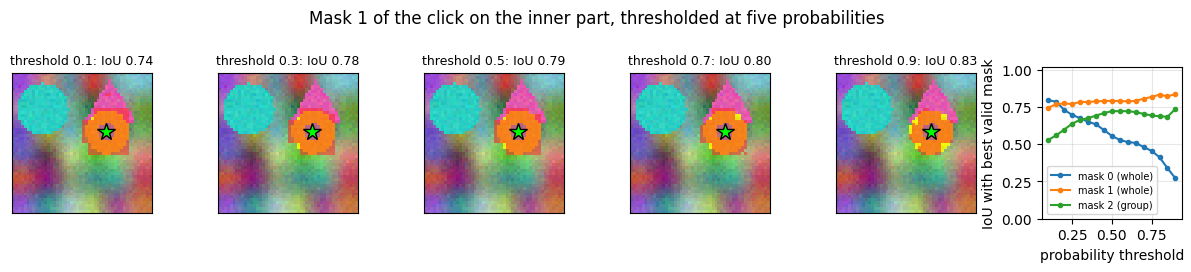

In [50]:
DEMO_LOGITS = CLICK_LOGITS[even(yc) // STEP, even(xc) // STEP]                     # (3, H, W) for the click on the part
d_valid, _ = valid_masks(inst_d, part_d, grp_d, even(yc), even(xc))
THRS = np.linspace(0.1, 0.9, 17)

def iou_np(a, b):
    return (a & b).sum() / max((a | b).sum(), 1)

def best_valid_iou(mask):
    """IoU of a binary mask with whichever valid mask (part, whole, group) it matches best, and that mask's name."""
    scores = {name: iou_np(mask, m) for name, m in d_valid.items()}
    name = max(scores, key=scores.get)
    return scores[name], name

def prob_maps():
    return 1 / (1 + np.exp(-DEMO_LOGITS))

PROB = prob_maps()
SWEEP = np.array([[best_valid_iou(PROB[k] > t)[0] for t in THRS] for k in range(3)])       # (3, thresholds)
names = [best_valid_iou(PROB[k] > 0.5)[1] for k in range(3)]
fig, axes = plt.subplots(1, 6, figsize=(12, 2.6))
k_show = int(np.argmax(CLICK_IOU[even(yc) // STEP, even(xc) // STEP]))
for ax, t in zip(axes[:5], [0.1, 0.3, 0.5, 0.7, 0.9]):
    ax.imshow(overlay(demo_img, PROB[k_show] > t)); draw_points(ax, [(even(xc), even(yc))], [1])
    ax.set_title(f'threshold {t:.1f}: IoU {best_valid_iou(PROB[k_show] > t)[0]:.2f}', fontsize=9)
for k in range(3):
    axes[5].plot(THRS, SWEEP[k], 'o-', ms=3, label=f'mask {k} ({names[k]})')
axes[5].set_xlabel('probability threshold'); axes[5].set_ylabel('IoU with best valid mask'); axes[5].set_ylim(0, 1.02)
axes[5].legend(fontsize=7); axes[5].grid(alpha=0.3)
clear_axes(axes[:5]); plt.suptitle(f'Mask {k_show} of the click on the inner part, thresholded at five probabilities', y=1.03)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [51]:
def threshold_viewer(threshold=0.5, mask=k_show):
    binary = PROB[mask] > threshold
    iou, name = best_valid_iou(binary)
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(PROB[mask], cmap='magma', vmin=0, vmax=1); draw_points(axes[0], [(even(xc), even(yc))], [1])
    axes[0].set_title(f'mask {mask}: probability map', fontsize=9)
    axes[1].imshow(overlay(demo_img, binary)); draw_points(axes[1], [(even(xc), even(yc))], [1])
    axes[1].set_title(f'threshold {threshold:.2f}: {int(binary.sum())} px, IoU {iou:.2f} with "{name}"', fontsize=9)
    axes[2].plot(THRS, SWEEP[mask], 'o-', ms=3); axes[2].axvline(threshold, color='r', ls='--')
    axes[2].set_xlabel('threshold'); axes[2].set_ylabel('IoU with best valid mask'); axes[2].set_ylim(0, 1.02); axes[2].grid(alpha=0.3)
    axes[0].set_xticks([]); axes[0].set_yticks([]); axes[1].set_xticks([]); axes[1].set_yticks([])
    plt.tight_layout(); plt.show()

interact(threshold_viewer, threshold=FloatSlider(min=0.05, max=0.95, step=0.05, value=0.5, continuous_update=False),
         mask=IntSlider(min=0, max=2, step=1, value=k_show, continuous_update=False));

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='threshold', max=0.95, min=0…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Sequence-to-sequence segmentation (SETR)** | Patches become tokens, a standard Transformer keeps them at one resolution with global context from layer one, and a decoder (progressive upsampling or multi-level aggregation) turns the token map back into per-pixel scores. |
| **Hierarchical encoder (SegFormer)** | Overlapped patch merging gives strides 4, 8, 16 with local continuity; small patches at the first stage are affordable only because the keys and values are reduced. |
| **Efficient self-attention** | Reducing the key/value sequence by $R^2$ shrinks the attention matrix from $N \times N$ to $N \times N/R^2$; at $R = 1$ it is ordinary attention (asserted), at $N = 4096$ the measured time falls with $R$. |
| **Positional-encoding-free design** | A $3 \times 3$ depth-wise convolution inside the feed-forward block supplies position, so the encoder needs no positional embedding and runs at a new resolution without interpolation. |
| **Mask classification (MaskFormer)** | Predict $N$ (class, mask) pairs instead of a class per pixel; train with Hungarian matching; read out semantic labels by marginalising over queries. The same output also separates instances. |
| **Masked attention (Mask2Former)** | An attention mask built from the previous layer's mask restricts cross-attention to the query's own region; it is a boolean mask on the scores, verified against `nn.MultiheadAttention`. |
| **Promptable segmentation (SAM)** | The task is "return a valid mask for this prompt", and validity, not intent, is what ambiguity-aware outputs satisfy. |
| **Image encoder, prompt encoder, mask decoder** | The image is embedded once; a prompt is a positional encoding plus a label embedding; a two-way decoder returns three masks and an IoU score in one cheap pass. |
| **Three masks, minimum loss** | Back-propagating only the best of three outputs lets the slots specialise (part, whole, group); the oracle IoU exceeds the top-1 IoU by exactly the residual ambiguity. |
| **Data engine and Grounded SAM** | Model-in-the-loop annotation scaled masks to a billion; an open-set detector turns text into box prompts, so SAM gains names without retraining. |

### The architectures at a glance

| Model | Output | Encoder | Decoder | Training signal | Inference |
|---|---|---|---|---|---|
| **SETR** | class per pixel | ViT (fixed resolution) | PUP or MLA | pixel-wise CE | argmax per pixel |
| **SegFormer** | class per pixel | hierarchical, efficient attention, Mix-FFN | all-MLP | pixel-wise CE | argmax per pixel |
| **MaskFormer** | $N$ (class, mask) pairs | any backbone + pixel decoder | Transformer decoder with queries | Hungarian matching + CE + mask losses | marginalise over queries |
| **Mask2Former** | $N$ (class, mask) pairs | backbone + MSDeformAttn pixel decoder | masked-attention decoder | same, with masked attention, multi-scale features fed round-robin to the decoder layers, and a point-sampled mask loss | same, for semantic, instance, panoptic |
| **SAM** | 3 masks + IoU per prompt | pre-trained ViT, run once | prompt encoder + two-way mask decoder | min-over-3 mask loss + IoU MSE | rank by predicted IoU, refine with more points |

### What we verified, not just asserted

- the from-scratch `MHA` matches `nn.MultiheadAttention` with copied weights, and `attention()` matches `F.scaled_dot_product_attention`, with and without a boolean mask (`allclose`)
- `EfficientAttention(R=1)` is ordinary attention; a plain MLP is permutation-equivariant and the Mix-FFN is not
- the Hungarian assignment from `scipy` equals a brute-force enumeration of every assignment, on random costs and on a real cost matrix of the trained model
- masked attention as a boolean `keep` mask equals the slide's additive $0/-\infty$ form and `nn.MultiheadAttention` with the same mask; an all-masked query gives NaN, which is why the fallback exists
- the marginalisation identity $\sum_c \mathrm{score}[c] = \sum_i p_i(\text{object})\, m_i$ holds numerically
- every model really learned: SETR, SegFormer, MaskFormer and Mask2Former reach measured validation mIoUs far above the all-background baseline, and TinySAM's top-1 mask matches the object better when the click has a single valid mask, while its IoU head scores object clicks above background clicks

## Exercises

1. **Patch size against cost in SETR.** Build `ViTEncoder(patch=2)` (a $24 \times 24$ grid, 576 tokens) with a `PUPDecoder(n_up=1)`, train it with `train_semantic` and report the validation mIoU, the size of one attention matrix and the seconds per step next to the patch-4 model. Is the finer grid worth its $16\times$ larger attention matrix on this dataset?

2. **Reduction ratio ablation in SegFormer.** Train `SegFormer(R=(1, 1, 1))`, `SegFormer(R=(2, 2, 1))` (the default) and `SegFormer(R=(4, 2, 1))` with the same recipe and report mIoU and training time for each. Then re-run section 2f at $64 \times 64$ for all three: does the reduction change how well the model transfers to a new resolution?

3. **The no-object weight.** Retrain the $N = 8$ MaskFormer with `no_object_weight=1.0` (edit the default of `mask_cls_loss`) and compare with 0.1: report the mIoU and, using `panoptic_inference`, how many queries per validation image claim a real class with probability above 0.5. Which setting produces more empty predictions, and which more duplicates?

4. **A single-output SAM.** Train `TinySAM(n_masks=1)` with the same prompts and evaluate it with the centre-click protocol of section 7c. *In our runs the three-mask model's oracle IoU exceeds its top-1 IoU (both printed in 7c); a one-mask model has no oracle to fall back on, so its single IoU should sit near the three-mask top-1 or below it on the ambiguous clicks.* Report the IoU split by the number of valid masks, as in 7c, and say whether the ambiguity-aware design paid off.

5. **Box prompts.** SAM encodes a box as two corner points with two extra label embeddings (top-left and bottom-right). Extend `PointEncoder` to five labels, derive a box from every training target mask (`np.argwhere` gives the extremes), train with a mix of point and box prompts, and measure the centre-click and box-prompt IoU on the validation objects. Boxes remove most of the ambiguity, so the top-1 and oracle numbers should converge; check that they do.

6. **A stability score for automatic masks.** SAM's fully-automatic stage also discards unstable masks: those whose binarisations at logit thresholds $+\delta$ and $-\delta$ differ (IoU below 0.95). Add the filter to `automatic_masks`, sweep $\delta$, and count on several validation images how many spurious masks it removes and whether any true object is lost.